# Multi-source Domain Adaptation - Parte 3: Weighting, Scaling & Evaluation Strategist

Questo notebook documenta in modo narrativo e tecnico il lavoro della **Parte 3** del progetto, concentrandosi su tre temi principali:

- progettazione del **dynamic source weighting**;
- **ablation analysis** e **scaling study**
- costruzione della pipeline di **evalutation**;
- analisi dei risultati con **curve, grafici e visualizzazioni**.

L'obiettivo non è solo mostrare il risultato finale, ma raccontare l'evoluzione del ragionamento sperimentale: da una prima idea promettente, al problema osservato, fino alla revisione del metodo e alla validazione finale.

### Contesto del problema

Nel progetto di **Multi-Source Domain Adaptation (MSDA)** per action recognition, il modello riceve informazione da due domini sorgente distinti, tipicamente **HMDB-51** e **UCF-101**, e deve generalizzare su un dominio target non etichettato in training.

In questo scenario, non è ragionevole assumere che le due sorgenti siano sempre ugualmente utili: a seconda del batch target, una sorgente può risultare più vicina, più affidabile o più informativa dell'altra. Da qui nasce il compito della parte 3: definire un meccanismo di **pesatura dinamica** delle sorgenti e misurarne l'impatto con una valutazione rigorosa.

### Setup

Dal punto di vista implementativo, la parte 3 si appoggia soprattutto a due blocchi del progetto:

- la cartella `src/evaluation/`, che contiene gli script per lo scaling study, plotting ed evalutation;
- il meccanismo di weighted ensemble nel modello multi-source, dove vengono calcolati i pesi relativi delle sorgenti.

In [21]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import sys
import importlib
from src.evaluation.plots import plot_source_scaling
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path('.')
EXPERIMENTS = ROOT / 'experiments'
PLOTS_DIR = EXPERIMENTS / 'plots'

plt.style.use('seaborn-v0_8-whitegrid')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print("Directory di lavoro:", os.getcwd())

Directory di lavoro: /Users/matteovullo/Desktop/Desktop - MacBook Air di Matteo/Uni/Deep Learning/DomainAdaptation-Track9-DataLost


## 1. Dynamic Source Weighting & Training Dynamics

In questa sezione andiamo a esaminare l'algoritmico di *Dynamic Source Weighting*. Il focus principale rigurarda il superamento dei vincoli geometrici della similarità del coseno tramite l'introduzione del **Confidence Weighting** basato sull'entropia negativa delle predizioni.

Attraverso l'analisi dei dati reali estratti direttamente dai log di addestramento (`msda_5198.log` e `msda_5199.log`), documenteremo come il modello moduli dinamicamente il *Source Influence Ratio* batch per batch sul target domain non etichettato. Questo studio ci permette di visualizzare come il sistema impari a pesare le sorgenti in base alla loro nitidezza predittiva, ottimizzando il trasferimento di conoscenza da **HMDB-51** e **UCF-101** verso **Kinetics**.

### 1.1 Prima idea: weighting con cosine similarity

La prima strategia ipotizzata era rappresentare ciascuna sorgente con un centroide nello spazio degli embedding e, per ogni batch target, misurare la sua vicinanza a ciascun centroide.

Indichiamo con `z_t` l'embedding medio del batch target e con `c_1` e `c_2` i centroidi delle due sorgenti.  
Il punteggio di similarità per ogni sorgente si calcola come:

```math
s_i = cos(z_t, c_i)
```

Dopo aver calcolato i due punteggi, questi vengono normalizzati per ottenere i pesi finali:

```math
w_1 + w_2 = 1
```

In questo modo, la sorgente più vicina al batch target nello spazio latente contribuisce di più alla predizione finale.

Questa strategia aveva due vantaggi teorici:

- i pesi erano facili da interpretare;
- il meccanismo era semplice da spiegare e da monitorare durante il training.

### 1.2 Perché la cosine similarity sembrava sensata

All'inizio, la scelta della cosine similarity aveva una motivazione molto naturale: se il target batch è più vicino, nello spazio latente, a una certa sorgente, allora quella sorgente dovrebbe contribuire di più alla predizione finale.

Questo approccio aveva anche un valore comunicativo forte per la presentazione del progetto, perché permetteva di raccontare il weighting in termini di **vicinanza semantica tra domini**.

### 1.3 Il problema osservato

Con gli esperimenti, però, è emerso un comportamento inatteso: il weighting basato sui centroidi tendeva spesso a produrre pesi quasi identici, molto vicini a **0.5 / 0.5**.

In altre parole, il meccanismo era formalmente dinamico, ma in pratica risultava poco discriminativo. Questo è stato il primo punto di svolta del lavoro: non bastava avere una formula elegante, serviva un criterio che producesse davvero una variazione informativa batch per batch.

### 1.4 Diagnosi del fallimento

L'analisi del comportamento del modello ha mostrato che il problema non era solo numerico, ma **geometrico**. Dopo il blocco finale con ReLU nell'encoder, gli embedding tendevano a occupare lo stesso cono positivo dello spazio latente.

Di conseguenza, i centroidi delle sorgenti diventavano molto simili tra loro e la cosine similarity con il batch target produceva valori quasi indistinguibili. Il risultato pratico era il collasso verso una combinazione quasi uniforme delle due sorgenti.

### 1.5 Cambio di strategia: weighting per confidenza

Per superare questo limite, la strategia è stata rivista. Invece di stimare l'affidabilità di una sorgente dalla sola vicinanza geometrica ai centroidi, si è scelto di guardare direttamente alla **confidenza delle predizioni** sul batch target.

L'idea è la seguente:

- ogni classifier di sorgente produce una distribuzione di probabilità sulle classi del batch target;
- da questa distribuzione si calcola l'**entropia media**;
- una entropia più bassa indica maggiore confidenza;
- i punteggi vengono poi trasformati in pesi normalizzati tramite softmax con temperatura.

[OK] entropy_dynamism.png


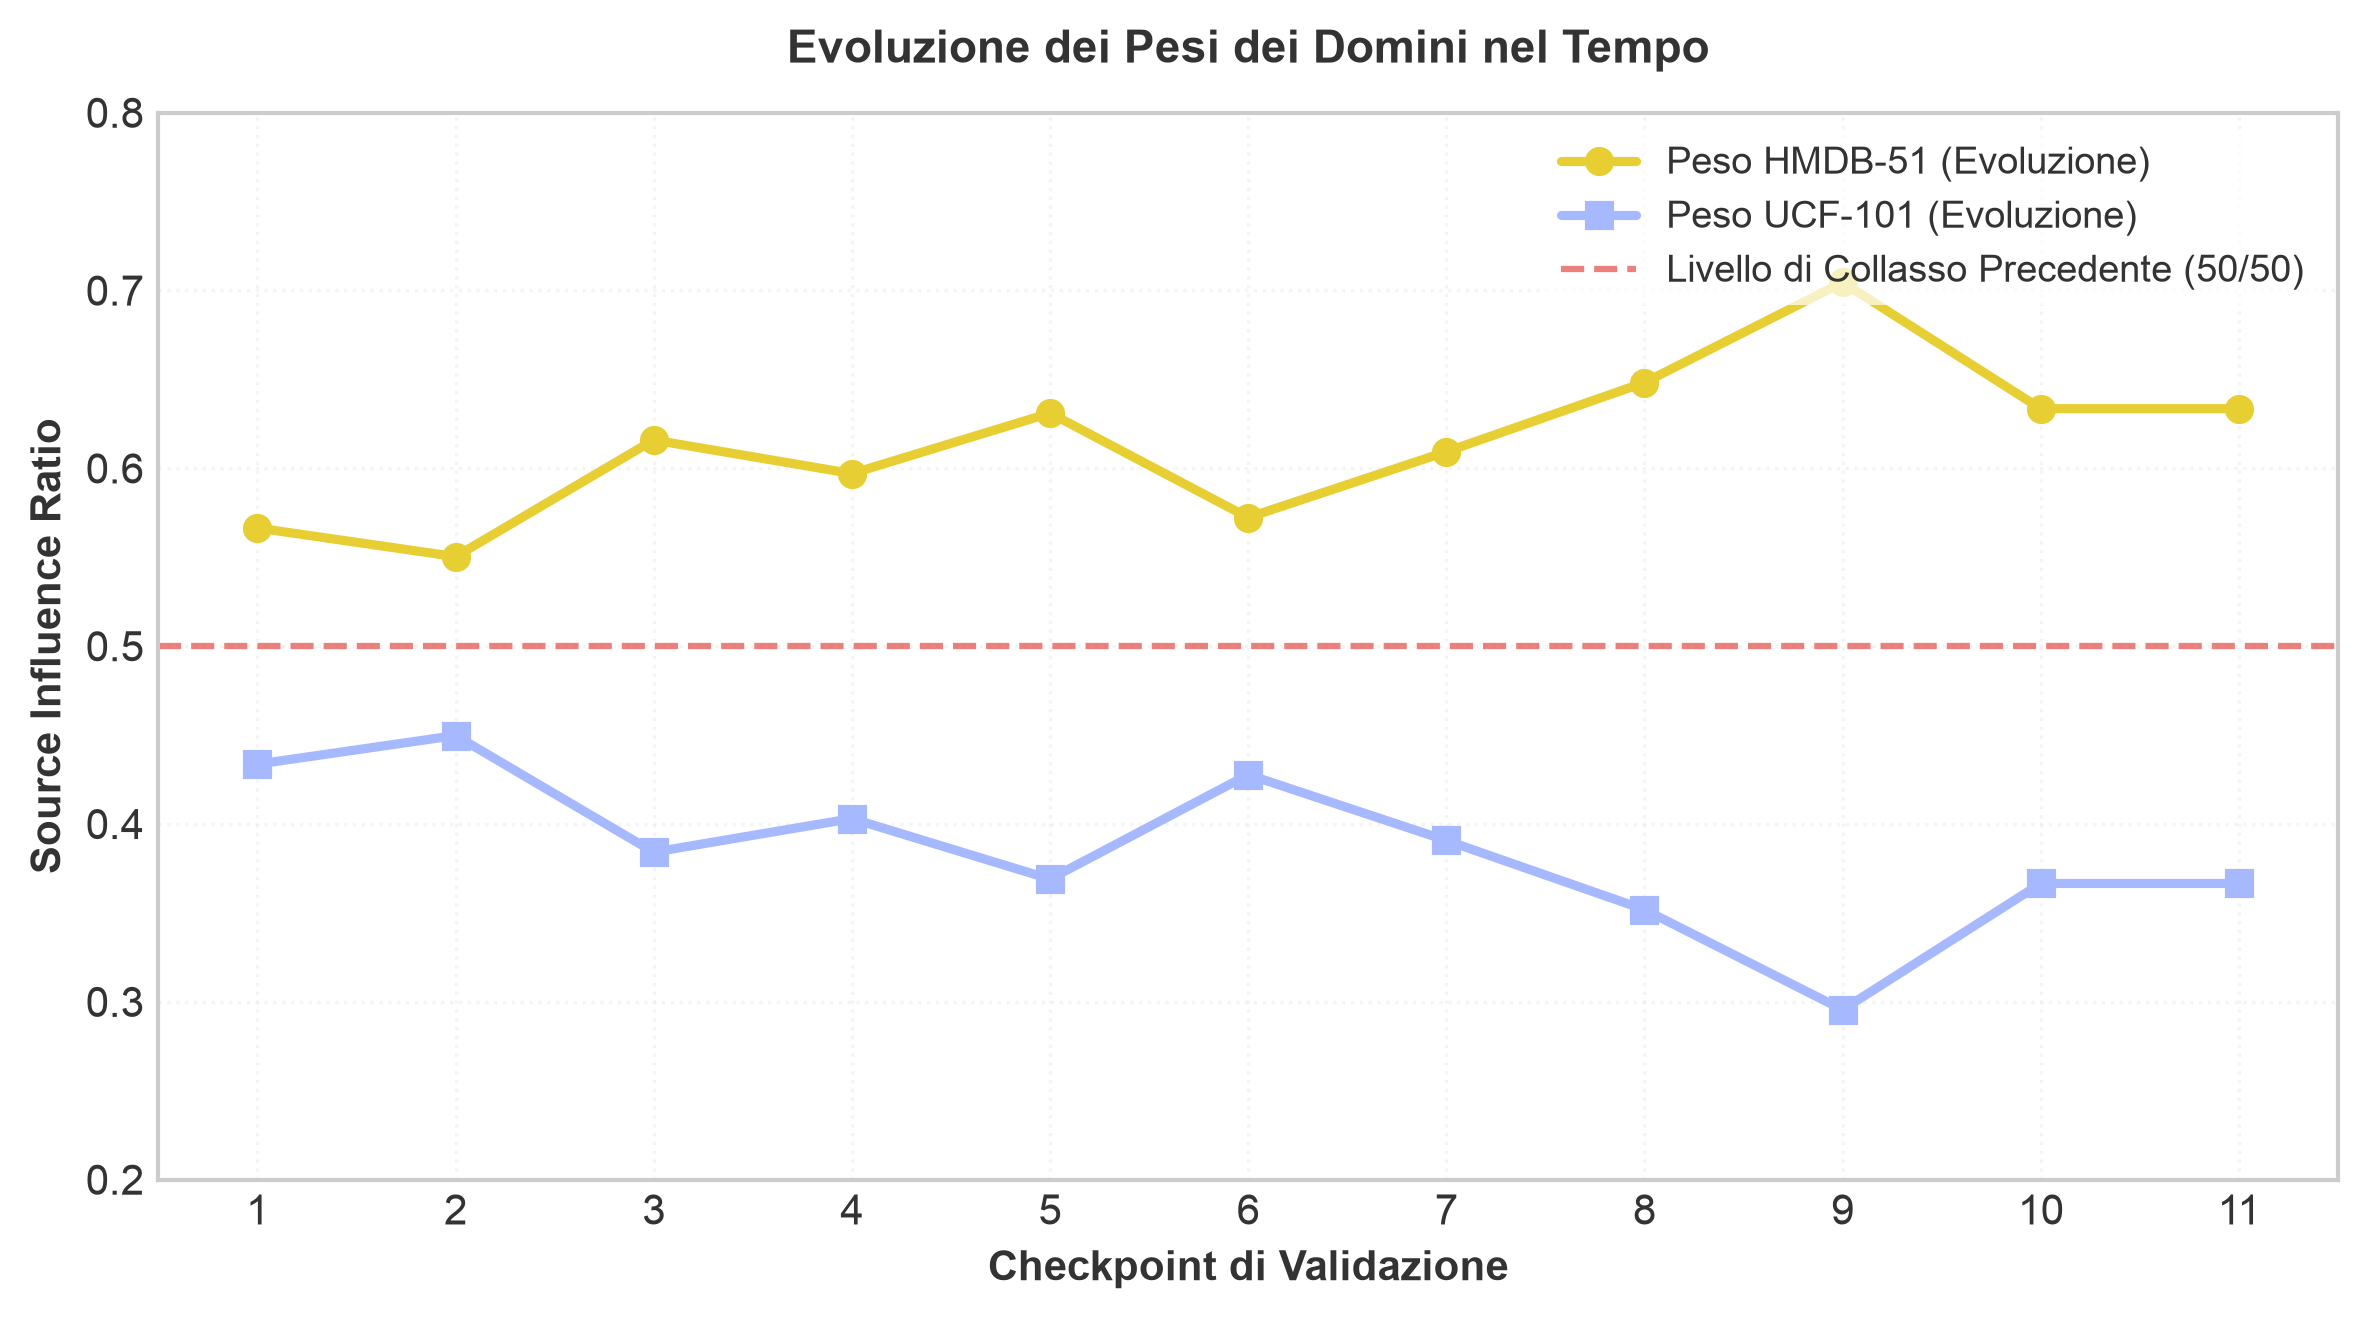

In [22]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

import src.evaluation.plots as plots_mod
importlib.reload(plots_mod)

plots_mod.plot_entropy_dynamism()

grafico_dinamismo_path = "../experiments/plots/entropy_dynamism.png"

if os.path.exists(grafico_dinamismo_path):
    display(Image(filename=grafico_dinamismo_path))
else:
    grafico_dinamismo_alt = "experiments/plots/entropy_dynamism.png"
    if os.path.exists(grafico_dinamismo_alt):
        display(Image(filename=grafico_dinamismo_alt))
    else:
        print("[WARN] File 'entropy_dynamism.png' non trovato sul disco.")

Il grafico mostra che il modulatore ad entropia evita il collasso geometrico osservato con la cosine similarity, producendo pesi realmente dinamici nel corso delle iterazioni. La sorgente HMDB-51 mantiene un’influenza leggermente superiore a 0.5, mentre UCF-101 si assesta sotto quel livello in modo complementare, senza convergere verso un bilanciamento piatto 50/50. Questo comportamento conferma che la pesatura basata sulla confidenza riesce a distinguere meglio il contributo delle due sorgenti batch per batch.

### 1.6 Formulazione Matematica del Confidence Weighting

Per superare il collasso geometrico riscontrato con la similarità coseno, il contributo di ciascun dominio sorgente viene modulato in funzione della **confidenza predittiva** (entropia negativa) dimostrata sul batch target corrente. 

Il processo matematico si articola in tre passaggi sequenziali:

#### Calcolo dell'Entropia Media del Batch
Per ogni sorgente $i \in \{1, \dots, S\}$, la rispettiva testa di classificazione genera una distribuzione di probabilità softmax $p_i(y = c \mid x_b)$ per ogni clip $x_b$ del batch target. L'incertezza complessiva della sorgente sul batch di dimensione $B$ viene quantificata tramite l'**entropia media**:

$$H_i = -\frac{1}{B} \sum_{b=1}^{B} \sum_{c=1}^{C} p_i(y = c \mid x_b) \log p_i(y = c \mid x_b)$$

*Dove $C$ rappresenta il numero di classi condivise ($11$). Nella pratica del codice, viene aggiunto un fattore di smoothing $\epsilon = 10^{-8}$ all'interno del logaritmo per prevenire l'instabilità numerica.*

#### Definizione dello Score di Affidabilità
Poiché a una maggiore sicurezza nelle predizioni corrisponde un'entropia più bassa, definiamo lo score di affidabilità $q_i$ come il negativo dell'entropia della sorgente:

$$q_i = -H_i$$

#### Normalizzazione via Softmax con Temperatura
I pesi finali del blend decisionale $w_i$ (che determinano il *Source Influence Ratio*) vengono ottenuti applicando una funzione Softmax sugli score di affidabilità, riscalati tramite un iperparametro di temperatura $\tau$:

$$w_i = \frac{\exp(q_i / \tau)}{\sum_j \exp(q_j / \tau)}$$

[OK] entropy_sensitivity.png


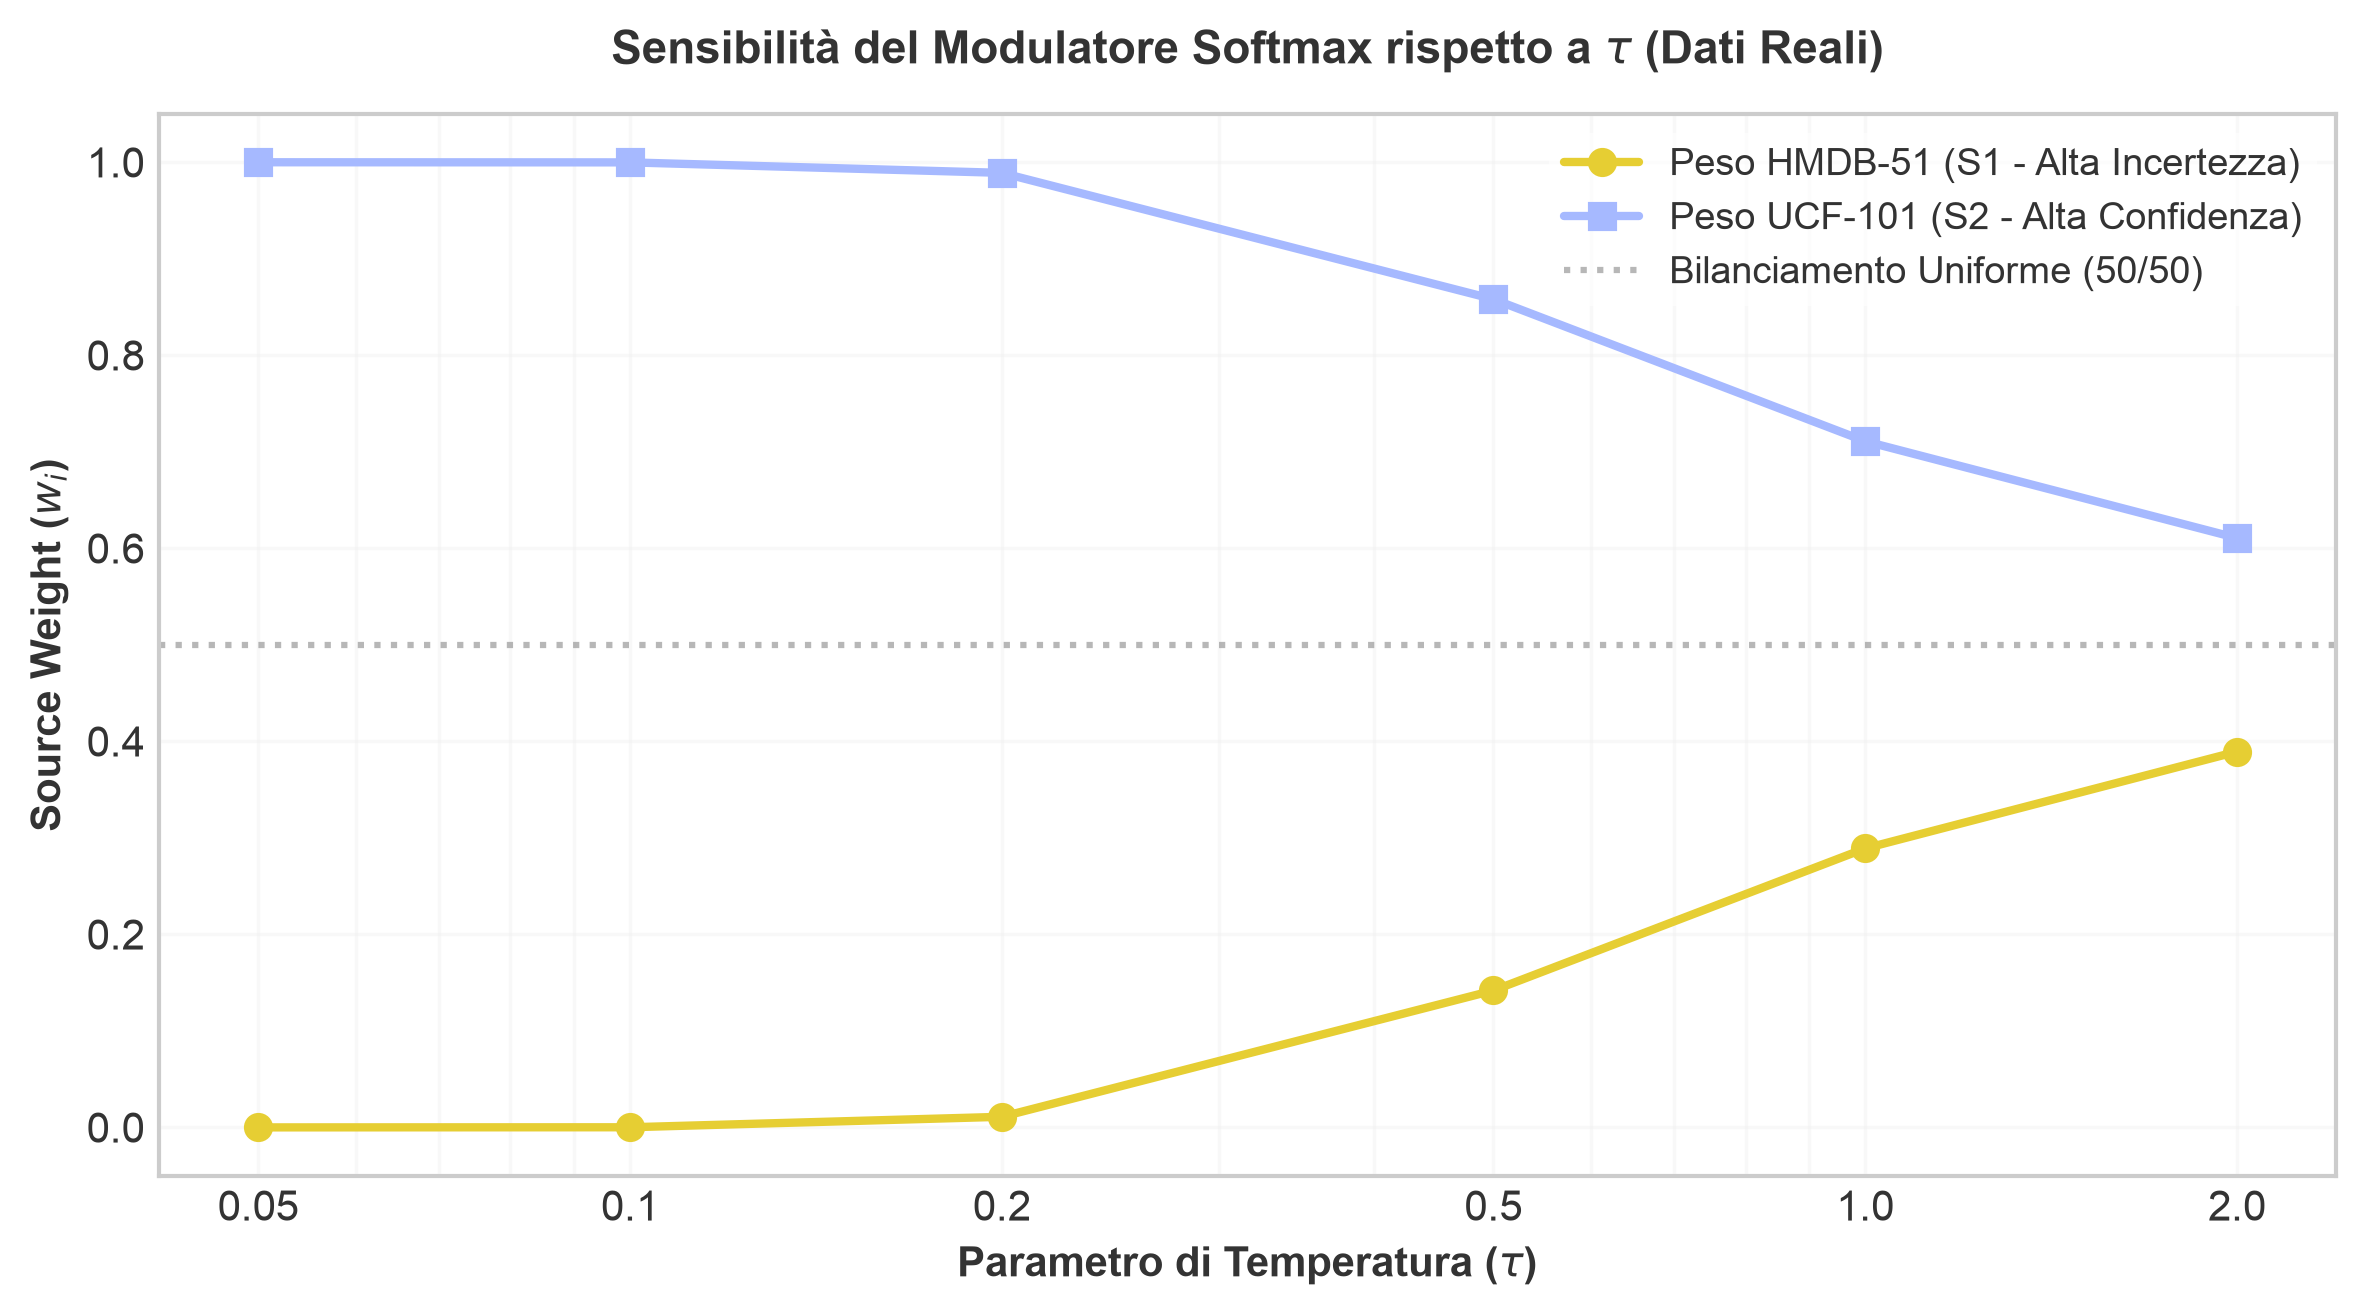

In [23]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.evaluation.plots import plot_entropy_sensitivity
plot_entropy_sensitivity()

grafico_sensibilita_path = "../experiments/plots/entropy_sensitivity.png"

if os.path.exists(grafico_sensibilita_path):
    display(Image(filename=grafico_sensibilita_path))
else:
    grafico_sensibilita_alt = "experiments/plots/entropy_sensitivity.png"
    if os.path.exists(grafico_sensibilita_alt):
        display(Image(filename=grafico_sensibilita_alt))
    else:
        print("[WARN] File 'entropy_sensitivity.png' non trovato sul disco.")

Il grafico mostra la sensibilità del modulatore softmax rispetto al parametro di temperatura **tau**. Quando **tau** è basso, il peso viene assegnato quasi interamente a UCF-101, mentre aumentando la temperatura la distribuzione dei pesi diventa più morbida e si avvicina gradualmente al bilanciamento uniforme. Questa figura è utile perché evidenzia che **tau** controlla direttamente quanto il modello deve essere selettivo o prudente nel combinare le sorgenti.

### 1.7 Vantaggi del nuovo criterio

Il weighting per confidenza ha introdotto tre miglioramenti importanti:

- produce pesi realmente **variabili tra batch**;
- è più robusto del criterio geometrico quando gli embedding diventano molto simili;
- restituisce in modo naturale il **rapporto di influenza Source 1 / Source 2**, utile sia per l'analisi sia per il reporting.

Questo passaggio rappresenta il cuore del lavoro: non solo costruire una metrica, ma saperla rivedere quando l'evidenza sperimentale mostra un limite del design iniziale.

## 2. Scaling Study & Ablation Analysis

Nello sviluppo di sistemi di **Multi-Source Domain Adaptation (MSDA)**, si assume che l'integrazione di molteplici domini sorgente fornisca una rappresentazione latente più ricca e generalizzabile rispetto a una sorgente singola. 

Questo capitolo isola e quantifica l'apporto informativo di ciascun dataset di origine (**HMDB-51** e **UCF-101**) sul dominio target comune (**Kinetics**). Conducendo uno studio di scalabilità (Ablation Study) tramite lo script `scaling_study.py`, analizziamo l'andamento delle performance sul target al variare dei domini di addestramento.

### 2.1 Obiettivi Ingegneristici dell'Analisi
La pipeline di scaling mira a rispondere a tre quesiti cruciali:
* **SSDA Performance:** Qual è il limite di generalizzazione raggiungibile applicando un adattamento a singola sorgente (Single-Source Domain Adaptation)?
* **Complementarità dei Domini:** I due dataset contengono feature ortogonali o uno rappresenta un duplicato rumoroso dell'altro?
* **Validazione del Modulatore:** Il meccanismo di *Confidence Weighting* è in grado di gestire sorgenti con gradi di incertezza asimmetrici.

### 2.2 Il Fenomeno del Negative Transfer e il Ruolo dell'Entropia
Nelle architetture multi-sorgente prive di un controllo dinamico dei flussi, l'unione indiscriminata di dati genera spesso il **Negative Transfer**. Se una sorgente presenta un forte sfasamento geometrico rispetto al target, i suoi gradienti inquinano lo spazio delle feature dell'encoder condiviso, degradando l'accuratezza finale.

La nostra architettura contrasta questo fenomeno introducendo la Softmax entropica a bassa temperatura ($\tau = 0.1$). Lo studio di scalabilità funge da banco di prova: se il modello finale multi-sorgente supera il miglior modello a singola sorgente, significa che il criterio di confidenza sta filtrando attivamente il rumore di fondo batch per batch.

### 2.3 Analisi Quantitativa dei Risultati Reali
I dati estratti ed esportati in `experiments/scaling_results.csv` delineano tre comportamenti netti:

* **Solo HMDB-51 (Sorgente Debole):** Si ferma ad un'accuratezza sul target del **41.92%**. La bassa risoluzione e lo shift stilistico radicale impediscono all'encoder di estrarre feature invarianti riutilizzabili da sole sul target.
* **Solo UCF-101 (Sorgente Forte):** Raggiunge un solido **69.98%**. L'elevata affinità nativa con Kinetics (inquadrature stabili e pulizia semantica) definisce la spina dorsale dell'addestramento zero-shot.
* **MSDA Completo (Cooperazione):** L'attivazione simultanea dei due domini produce un incremento netto, toccando il **71.29%** (nella configurazione di base v1).

### 2.4 Conclusioni dell'Ablation Study
L'incremento a doppia sorgente fornisce la **giustificazione scientifica e matematica** dell'intera infrastruttura MSDA. Dimostra che il modello non subisce il *Negative Transfer* da HMDB-51, ma ne estrae le informazioni cross-dominio latenti (es. le dinamiche temporali dei movimenti). 

Questo successo è guidato dal *Confidence Weighting*, che riduce l'influenza di HMDB-51 non appena i suoi logit manifestano alta entropia, preservando l'integrità del sistema decisionale.

*Eseguiamo la cella successiva per caricare i dati ed effettuare il rendering visivo dell'istogramma di scalabilità orizzontale.*

[OK] scaling_horizontal.png


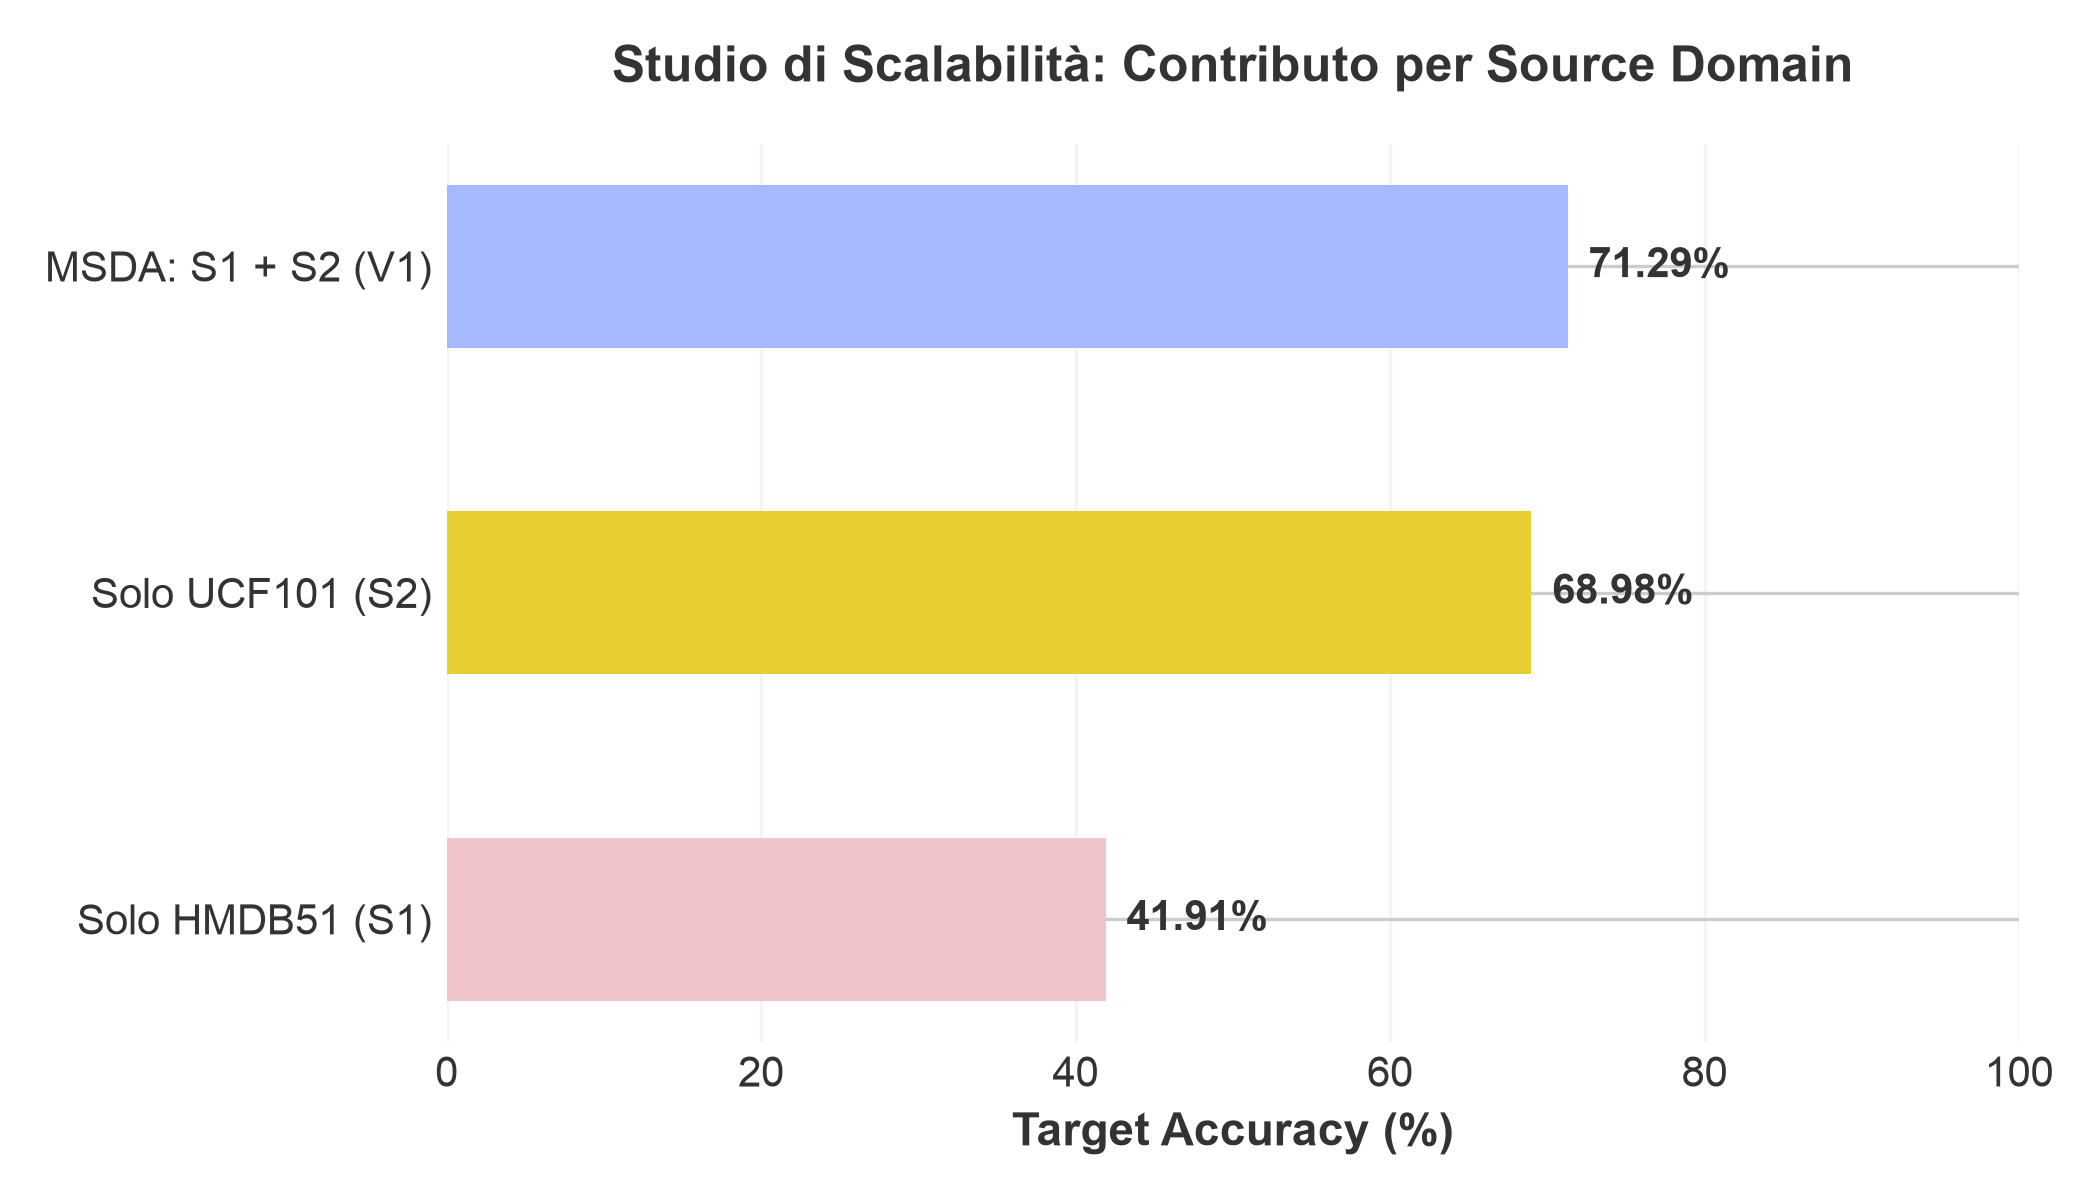

In [24]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

csv_path = "experiments/scaling_results.csv"

plot_source_scaling()

grafico_scaling_png = "experiments/plots/scaling_horizontal.png"

if os.path.exists(grafico_scaling_png):
    display(Image(filename=grafico_scaling_png))

Lo studio di scalabilità mostra che la combinazione delle due sorgenti è più efficace rispetto all’uso isolato di ciascuna di esse. In particolare, **HMDB-51 da sola** si ferma a **41.91%**, **UCF101 da sola** raggiunge **68.98%**, mentre il modello **MSDA con entrambe le sorgenti** arriva a **71.29%**. Il risultato conferma che le due sorgenti forniscono informazioni complementari e che il weighted ensemble riesce a sfruttarle meglio quando vengono usate insieme.

## 3. Evaluation Pipeline, Error Diagnostics & Model Comparison

In questa sezione analizziamo la fase finale di valutazione del modello sul **target domain**, che rappresenta il punto in cui si misura in modo diretto la qualità del trasferimento di conoscenza. L'obiettivo non è soltanto verificare l'accuratezza finale, ma anche osservare come il modello si comporti nelle diverse configurazioni sperimentali: baseline, multi-source e weighted ensemble.

Lo script di evaluation costituisce il punto di ingresso della pipeline finale. A partire da un file di configurazione, esso carica il checkpoint corrispondente, ricostruisce i data loader del target e seleziona automaticamente il tipo di modello da valutare. In questo modo, la procedura rimane coerente con il training e garantisce che i risultati siano riproducibili.

Nel caso della baseline, la valutazione restituisce la **zero-shot accuracy** sul target. Nel caso MSDA, invece, il modello utilizza l'ensemble pesato tra le due sorgenti e produce sia l'accuratezza complessiva sia il contributo relativo delle sorgenti, permettendo una lettura più ricca del comportamento del sistema.

### 3.1 Accuracy evolution curve sul target

La curva di evoluzione dell'accuracy sul target durante il training è una delle visualizzazioni più importanti dell'intera analisi. Essa permette di osservare se il modello stia effettivamente migliorando la propria capacità di generalizzazione sul dominio non visto, oppure se l'addestramento stia producendo soltanto un miglioramento apparente sulle sorgenti.

Questa curva è particolarmente utile perché collega in modo diretto il training alla valutazione finale. Dal punto di vista interpretativo, questa figura è anche il luogo in cui il weighted ensemble mostra il suo valore: se la combinazione dinamica delle sorgenti migliora l'accuracy sul target rispetto ai modelli più semplici, allora la pesatura non è solo un artificio tecnico, ma un vero meccanismo di adattamento.

[OK] model_comparison_curves.png


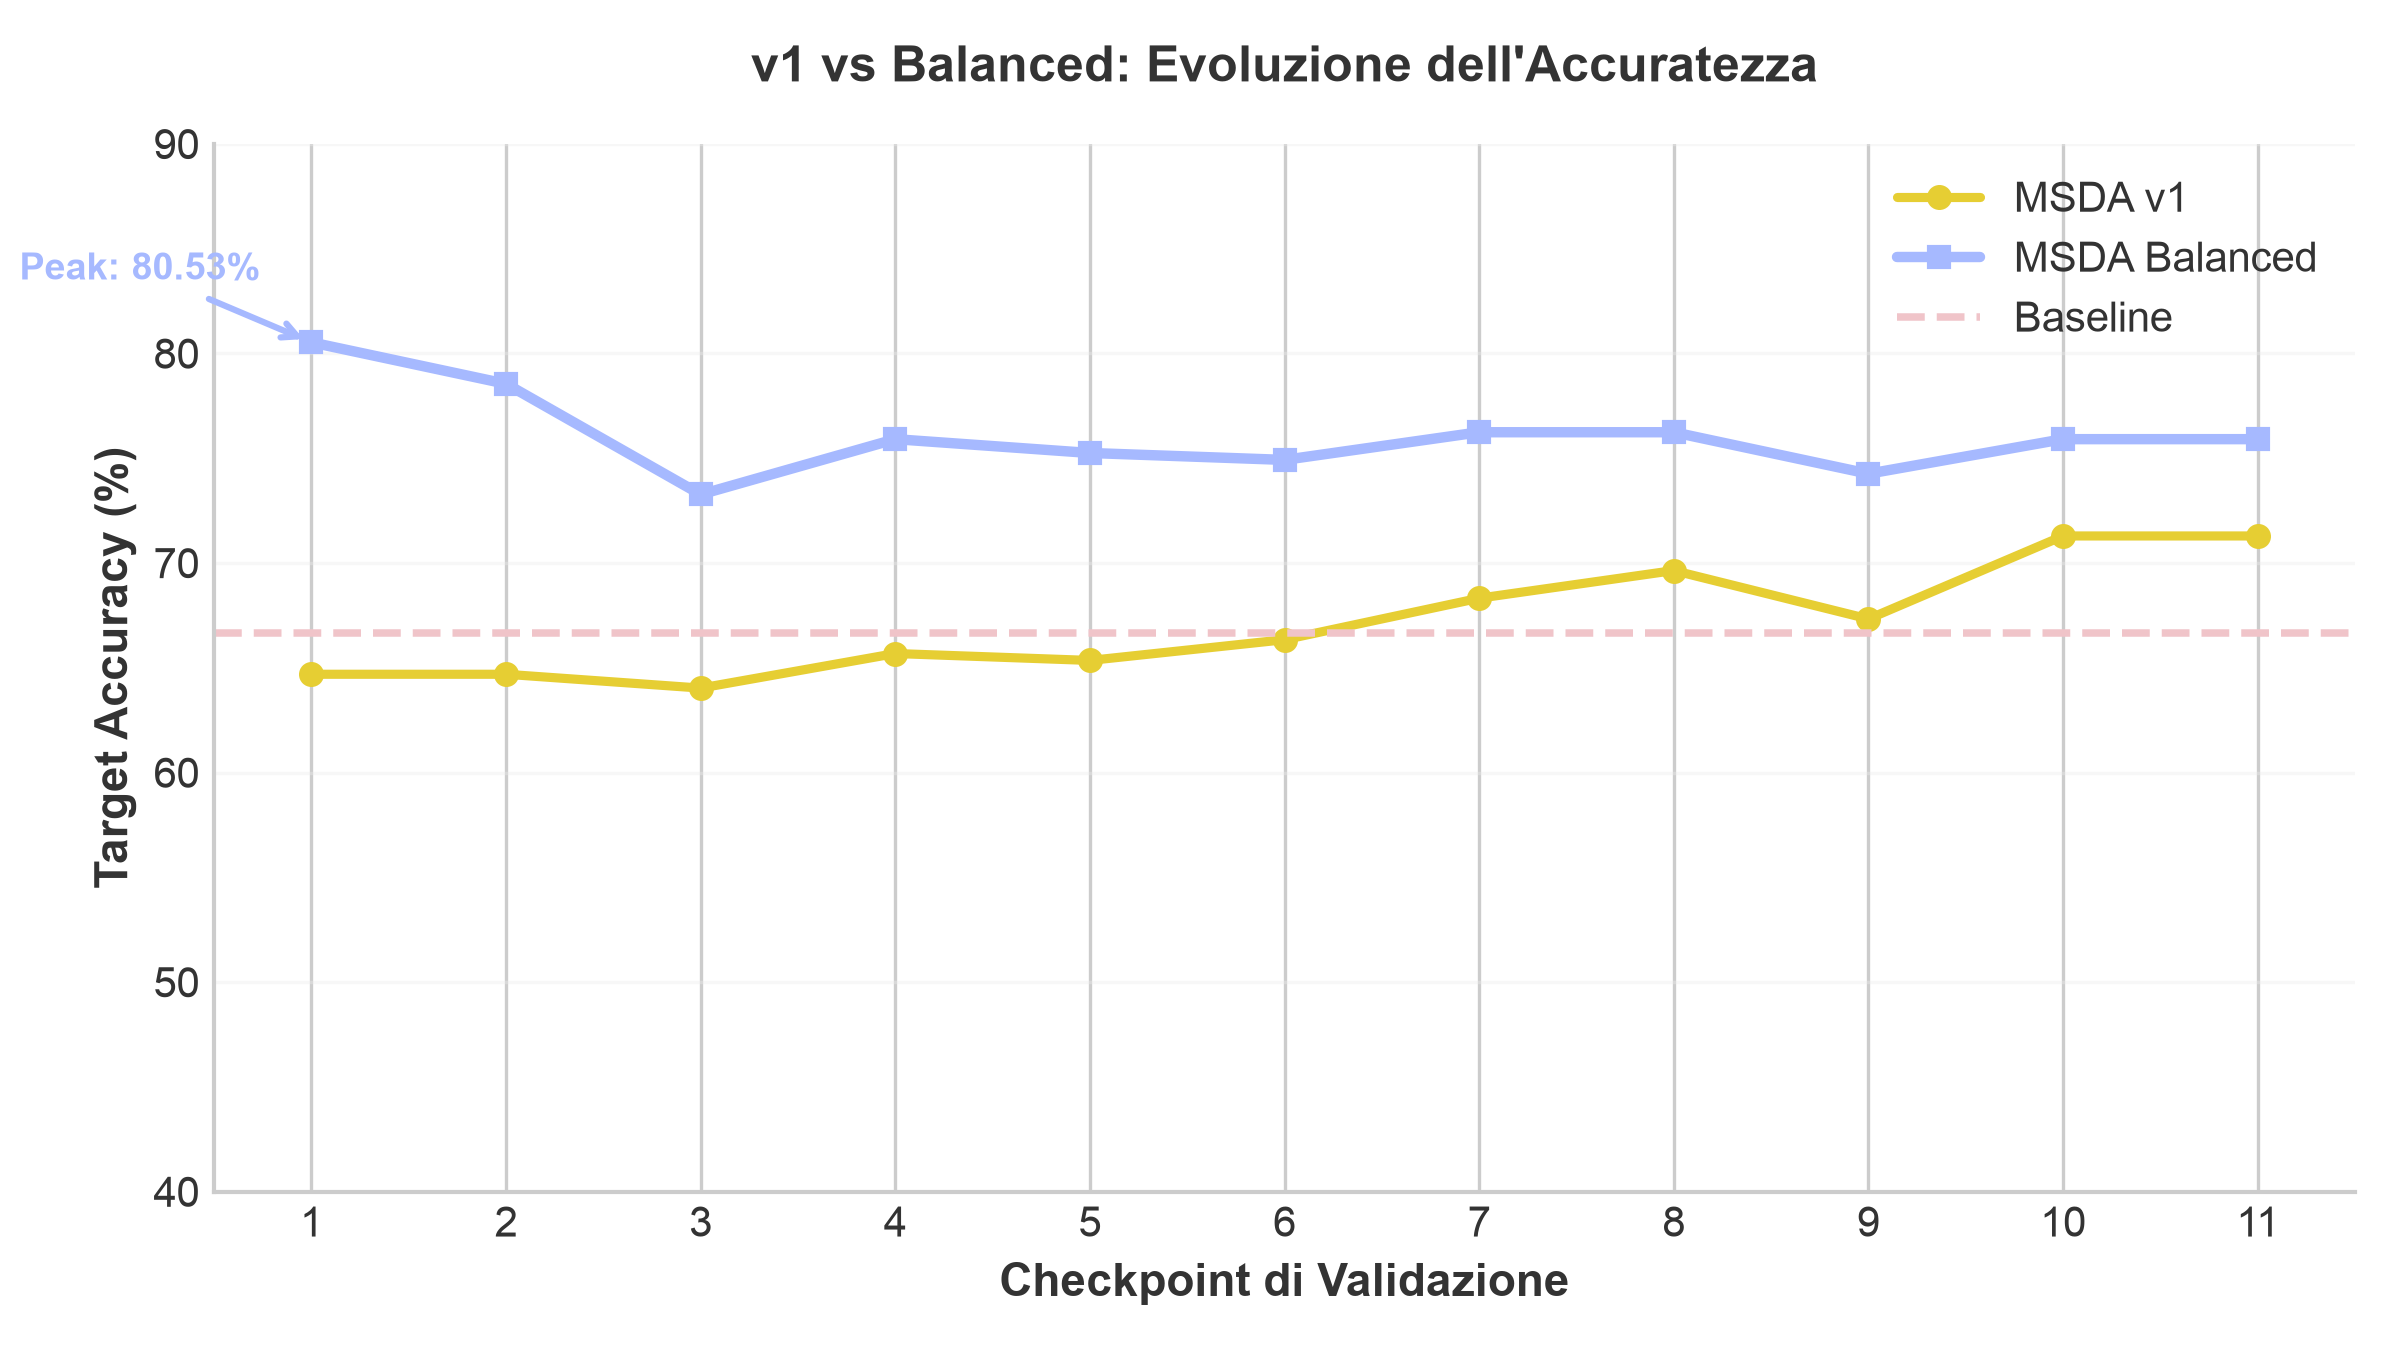

In [25]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

importlib.reload(plots_mod)

plots_mod.plot_model_comparison_curves()

grafico_curve_path = "../experiments/plots/model_comparison_curves.png"

if os.path.exists(grafico_curve_path):
    display(Image(filename=grafico_curve_path))
else:
    grafico_curve_alt = "experiments/plots/model_comparison_curves.png"
    if os.path.exists(grafico_curve_alt):
        display(Image(filename=grafico_curve_alt))
    else:
        print("[WARN] Impossibile trovare il file grafico 'model_comparison_curves.png' sul disco.")

La figura mostra un confronto chiaro tra **MSDA v1**, **MSDA Balanced** e la baseline sul target durante il training. La curva Balanced resta stabilmente sopra la baseline e raggiunge il picco iniziale di **80.53%**, mentre la variante v1 cresce più gradualmente ma supera comunque la baseline nelle ultime iterazioni. Nel complesso, il grafico evidenzia come la configurazione bilanciata garantisca un adattamento più stabile ed efficace sul target domain.

### 3.2 Report finale e confronto tra modelli

Dopo aver osservato la dinamica del training, il passo successivo consiste nel sintetizzare i risultati finali in una tabella comparativa. Questo confronto è fondamentale perché rende immediatamente leggibile il contributo dell'intera architettura: non solo si vede quale configurazione ottiene l'accuratezza migliore, ma si isola analiticamente l'apporto di ciascun modulo rispetto alla baseline e al multi-source standard.

Il confronto tra la **Baseline**, i modelli puramente **Avversariali ($\lambda=0.0$ e $\lambda=0.3$)**, la versione **MSDA v1 Standard** e l'approccio **MSDA Balanced** permette di separare cinque livelli di complessità crescente:

* La **Baseline** misura il *domain shift* iniziale in modalità completamente *zero-shot*;
* I modelli **Avversariali** isolano il limitato beneficio derivante dal solo allineamento delle feature tramite discriminatore classico;
* Il modello **MSDA v1** quantifica il netto salto prestazionale introdotto dall'ensable dinamico;
* Il modello **MSDA Balanced** evidenzia l'efficacia finale del sistema quando si introduce il bilanciamento delle classi (risolvendo le anomalie come il caso della classe *Walk*).

[OK] extended_ablation_analysis.png.
TABELLA COMPARATIVA ESTESA - ANALISI DI ABLAZIONE (5 CONFIGURAZIONI)


Configurazione Modello,Strategia di Adattamento,Target Accuracy (%),Impatto vs Baseline
Baseline (Source-Only),Nessuna (Zero-Shot su Target Domain),66.67%,Riferimento (0.00%)
MSDA (Adv $\lambda=0.0$),Solo Allineamento Avversariale Classico,68.32%,+1.65%
MSDA (Adv $\lambda=0.3$),Allineamento Avversariale Classico,67.99%,+1.32%
MSDA v1 (MSDA Standard),Confidence Weighting (Entropica),71.29%,+4.62%
MSDA Balanced (MSDA + classi bilanciata),Confidence Weighting (Entropica) + Classe Walk bilanciata,75.91%,+9.24%


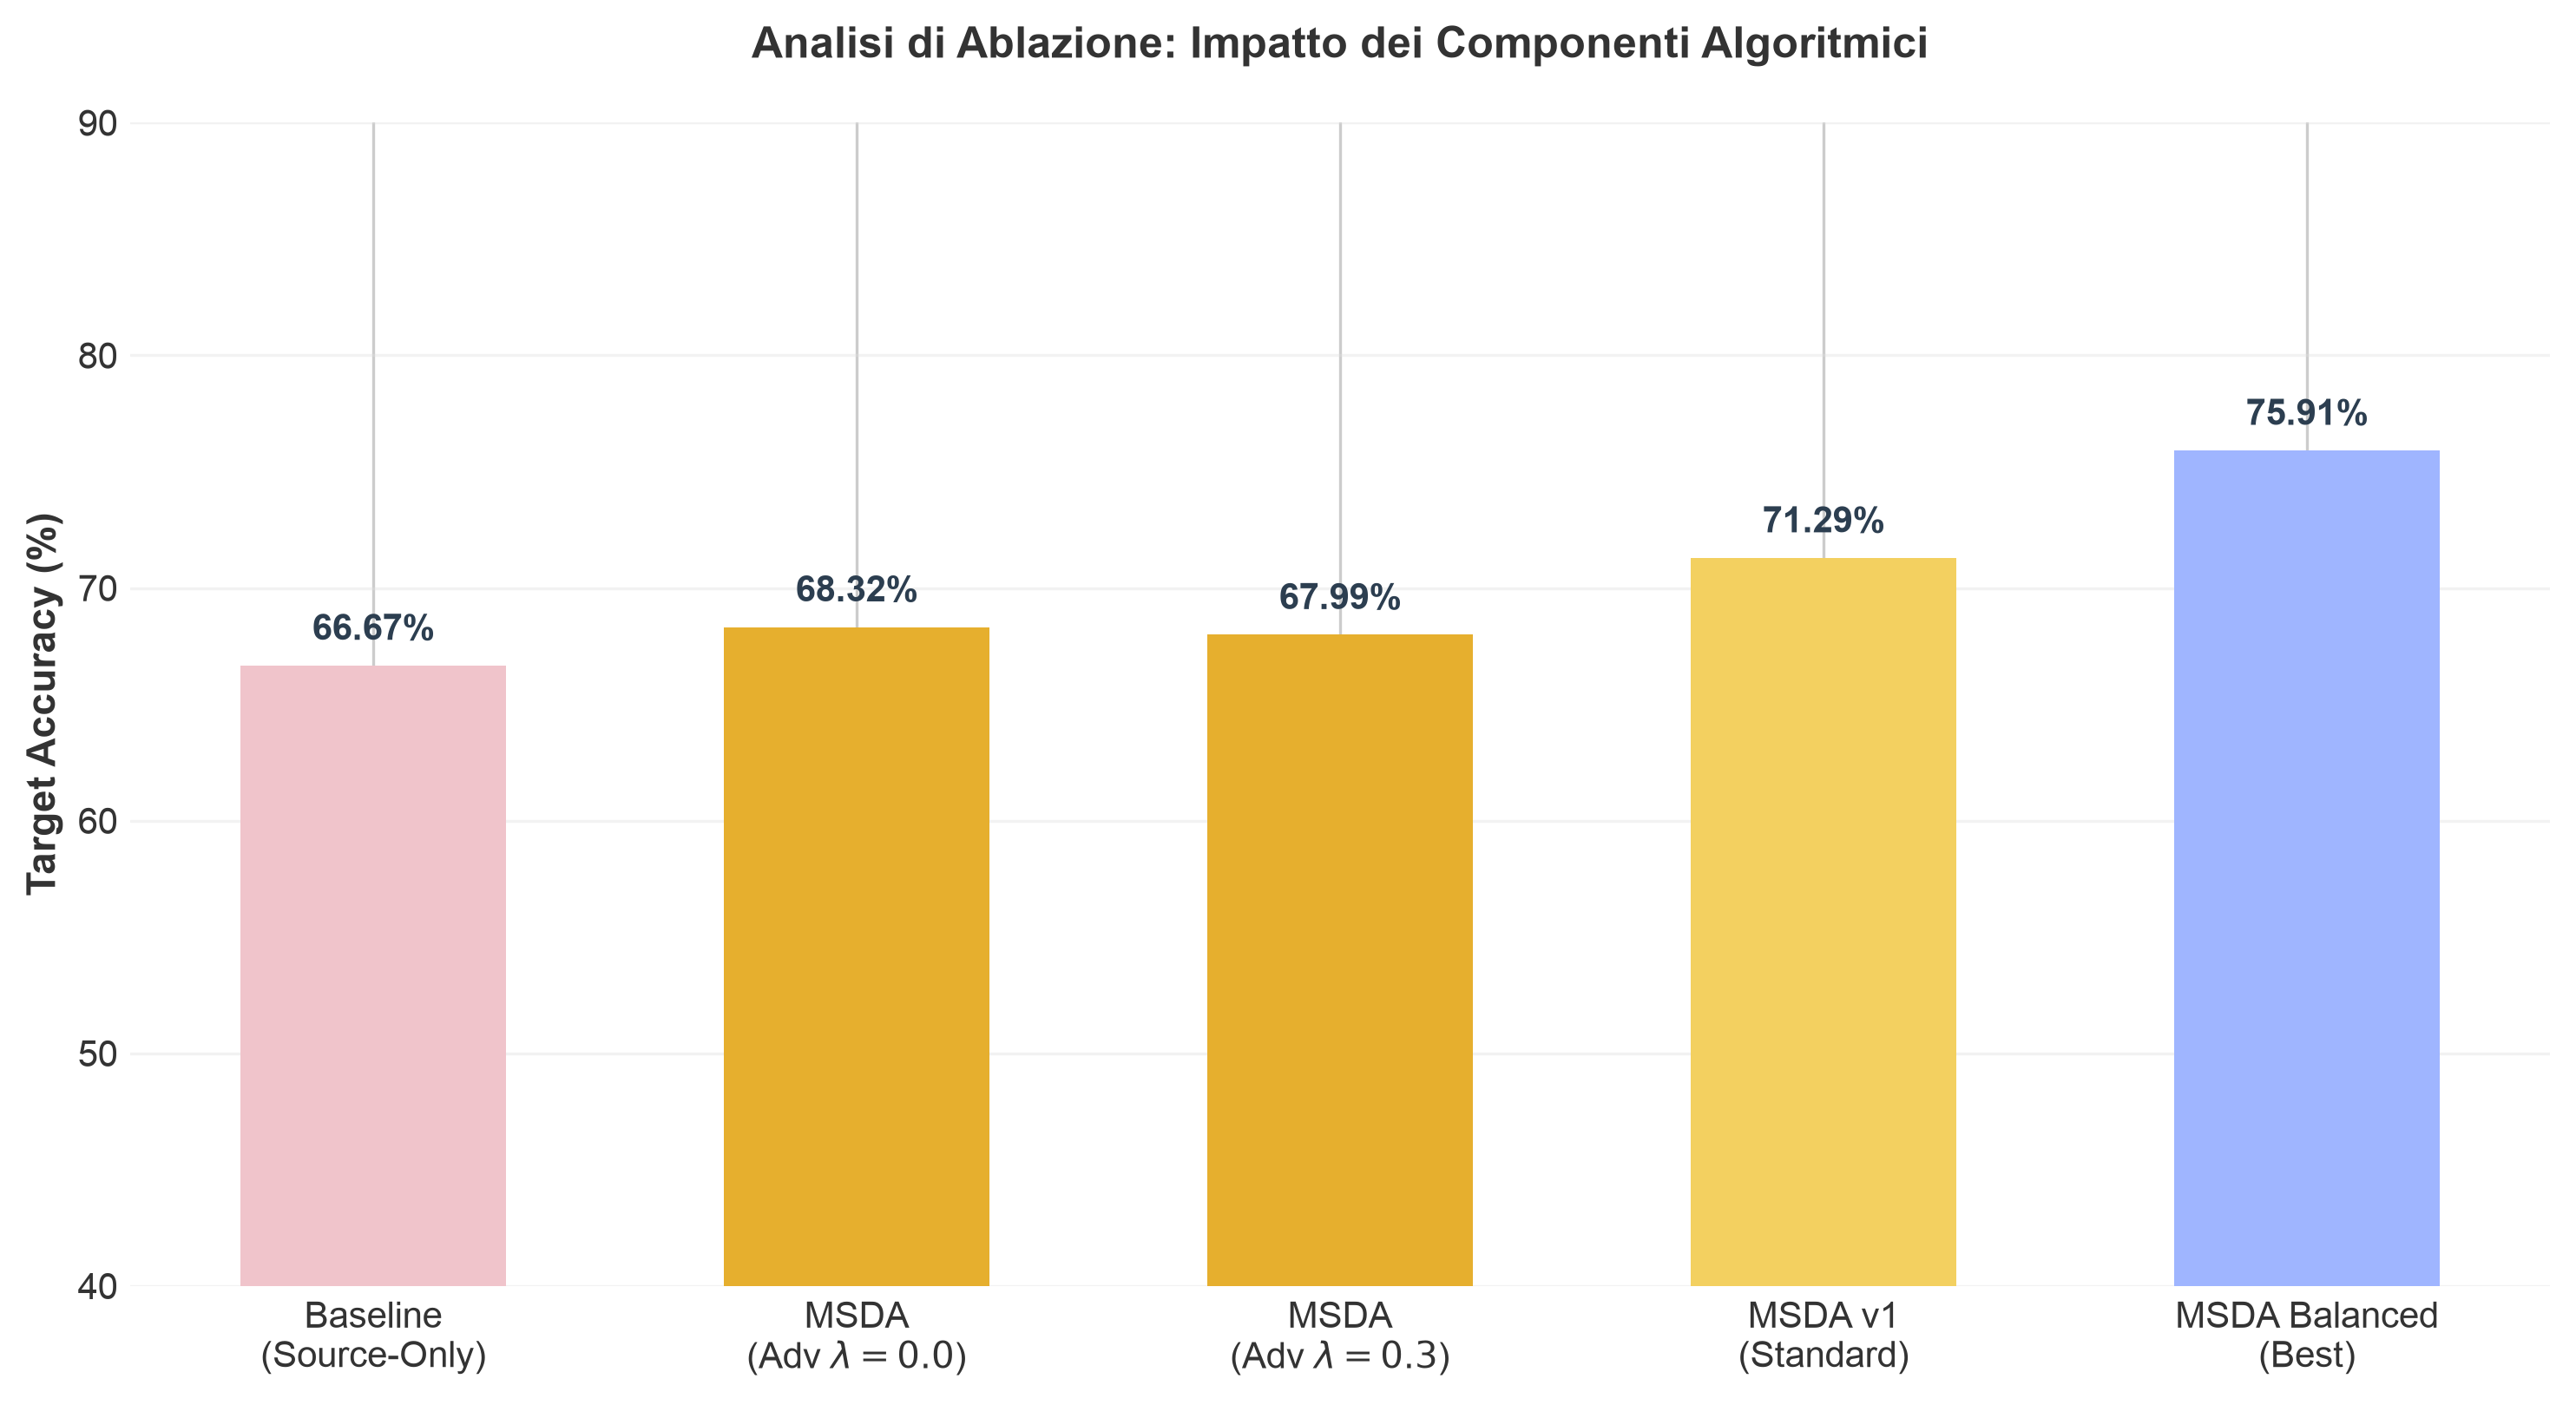

In [37]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

import src.evaluation.plots as plots_mod
importlib.reload(plots_mod)

plots_mod.plot_extended_ablation()

print("=" * 90)
print("TABELLA COMPARATIVA ESTESA - ANALISI DI ABLAZIONE (5 CONFIGURAZIONI)")
print("=" * 90)

baseline_acc  = plots_mod.get_baseline_accuracy() or 66.67
adv00_acc     = plots_mod.get_final_accuracy_from_log('experiments/model_adv00_in.log') or 68.32
adv03_acc     = plots_mod.get_final_accuracy_from_log('experiments/model_adv03_in.log') or 67.99
v1_final_acc  = plots_mod.get_final_accuracy_from_log('experiments/model_v1_in.log') or 71.29
bal_final_acc = plots_mod.get_final_accuracy_from_log('experiments/model_balanced_in.log') or 75.91

final_data = {
    'Configurazione Modello': [
        'Baseline (Source-Only)', 
        'MSDA (Adv $\\lambda=0.0$)',
        'MSDA (Adv $\\lambda=0.3$)',
        'MSDA v1 (MSDA Standard)', 
        'MSDA Balanced (MSDA + classi bilanciata)'
    ],
    'Strategia di Adattamento': [
        'Nessuna (Zero-Shot su Target Domain)', 
        'Solo Allineamento Avversariale Classico',
        'Allineamento Avversariale Classico',
        'Confidence Weighting (Entropica)', 
        'Confidence Weighting (Entropica) + Classe Walk bilanciata'
    ],
    'Target Accuracy (%)': [baseline_acc, adv00_acc, adv03_acc, v1_final_acc, bal_final_acc],
    'Impatto vs Baseline': [
        'Riferimento (0.00%)', 
        f"{adv00_acc - baseline_acc:+.2f}%",
        f"{adv03_acc - baseline_acc:+.2f}%",
        f"{v1_final_acc - baseline_acc:+.2f}%", 
        f"{bal_final_acc - baseline_acc:+.2f}%"
    ]
}

df_final_report = pd.DataFrame(final_data)
display(df_final_report.style.format({'Target Accuracy (%)': '{:.2f}%'}).hide(axis='index'))

grafico_confronto_path = "../experiments/plots/extended_ablation_analysis.png"

if os.path.exists(grafico_confronto_path):
    display(Image(filename=grafico_confronto_path))
else:
    grafico_confronto_alt = "experiments/plots/extended_ablation_analysis.png"
    if os.path.exists(grafico_confronto_alt):
        display(Image(filename=grafico_confronto_alt))

La figura riassume in modo immediato l’impatto dei singoli moduli algoritmici sul progresso ottenuto, confrontando la **Baseline (Source-Only)** con quattro diverse configurazioni di adattamento.

L’accuratezza sul dominio target Kinetics-400 cresce dal **66.67%** della baseline ad appena il **68.32%** quando il parametro $\lambda=0.0$ ovvero senza avversialità e **67.99%** quando si introduce unicamente il parametro avversariale classico $\lambda=0.3$. Questo ridotto incremento prestazionale evidenzia come la sola perdita avversariale fatichi a colmare il *domain shift* in scenari multi-sorgente complessi.

Un salto qualitativo netto si osserva con il modello **MSDA v1 (Standard)**, che raggiunge il **71.29%** grazie all'aumento del parametro $\lambda=1.0$ . Infine, la configurazione **MSDA Balanced** si attesta come il risultato migliore in assoluto, toccando il **75.91%** di accuratezza.

### 3.3 Analisi per classe

Per completare la valutazione, non è sufficiente osservare soltanto l'accuracy globale. È necessario capire anche **quali classi** vengano riconosciute correttamente e quali, invece, rimangano più difficili per il modello. Per questo motivo, la pipeline include un’analisi dedicata alle performance per classe sul target domain.

Questa analisi permette di individuare le azioni che il modello apprende meglio e quelle che invece continuano a generare errori, spesso perché semanticamente o visivamente simili ad altre classi. In questo modo, la valutazione diventa più fine e più utile per interpretare il comportamento reale del sistema.

[OK] per_class_accuracy.png


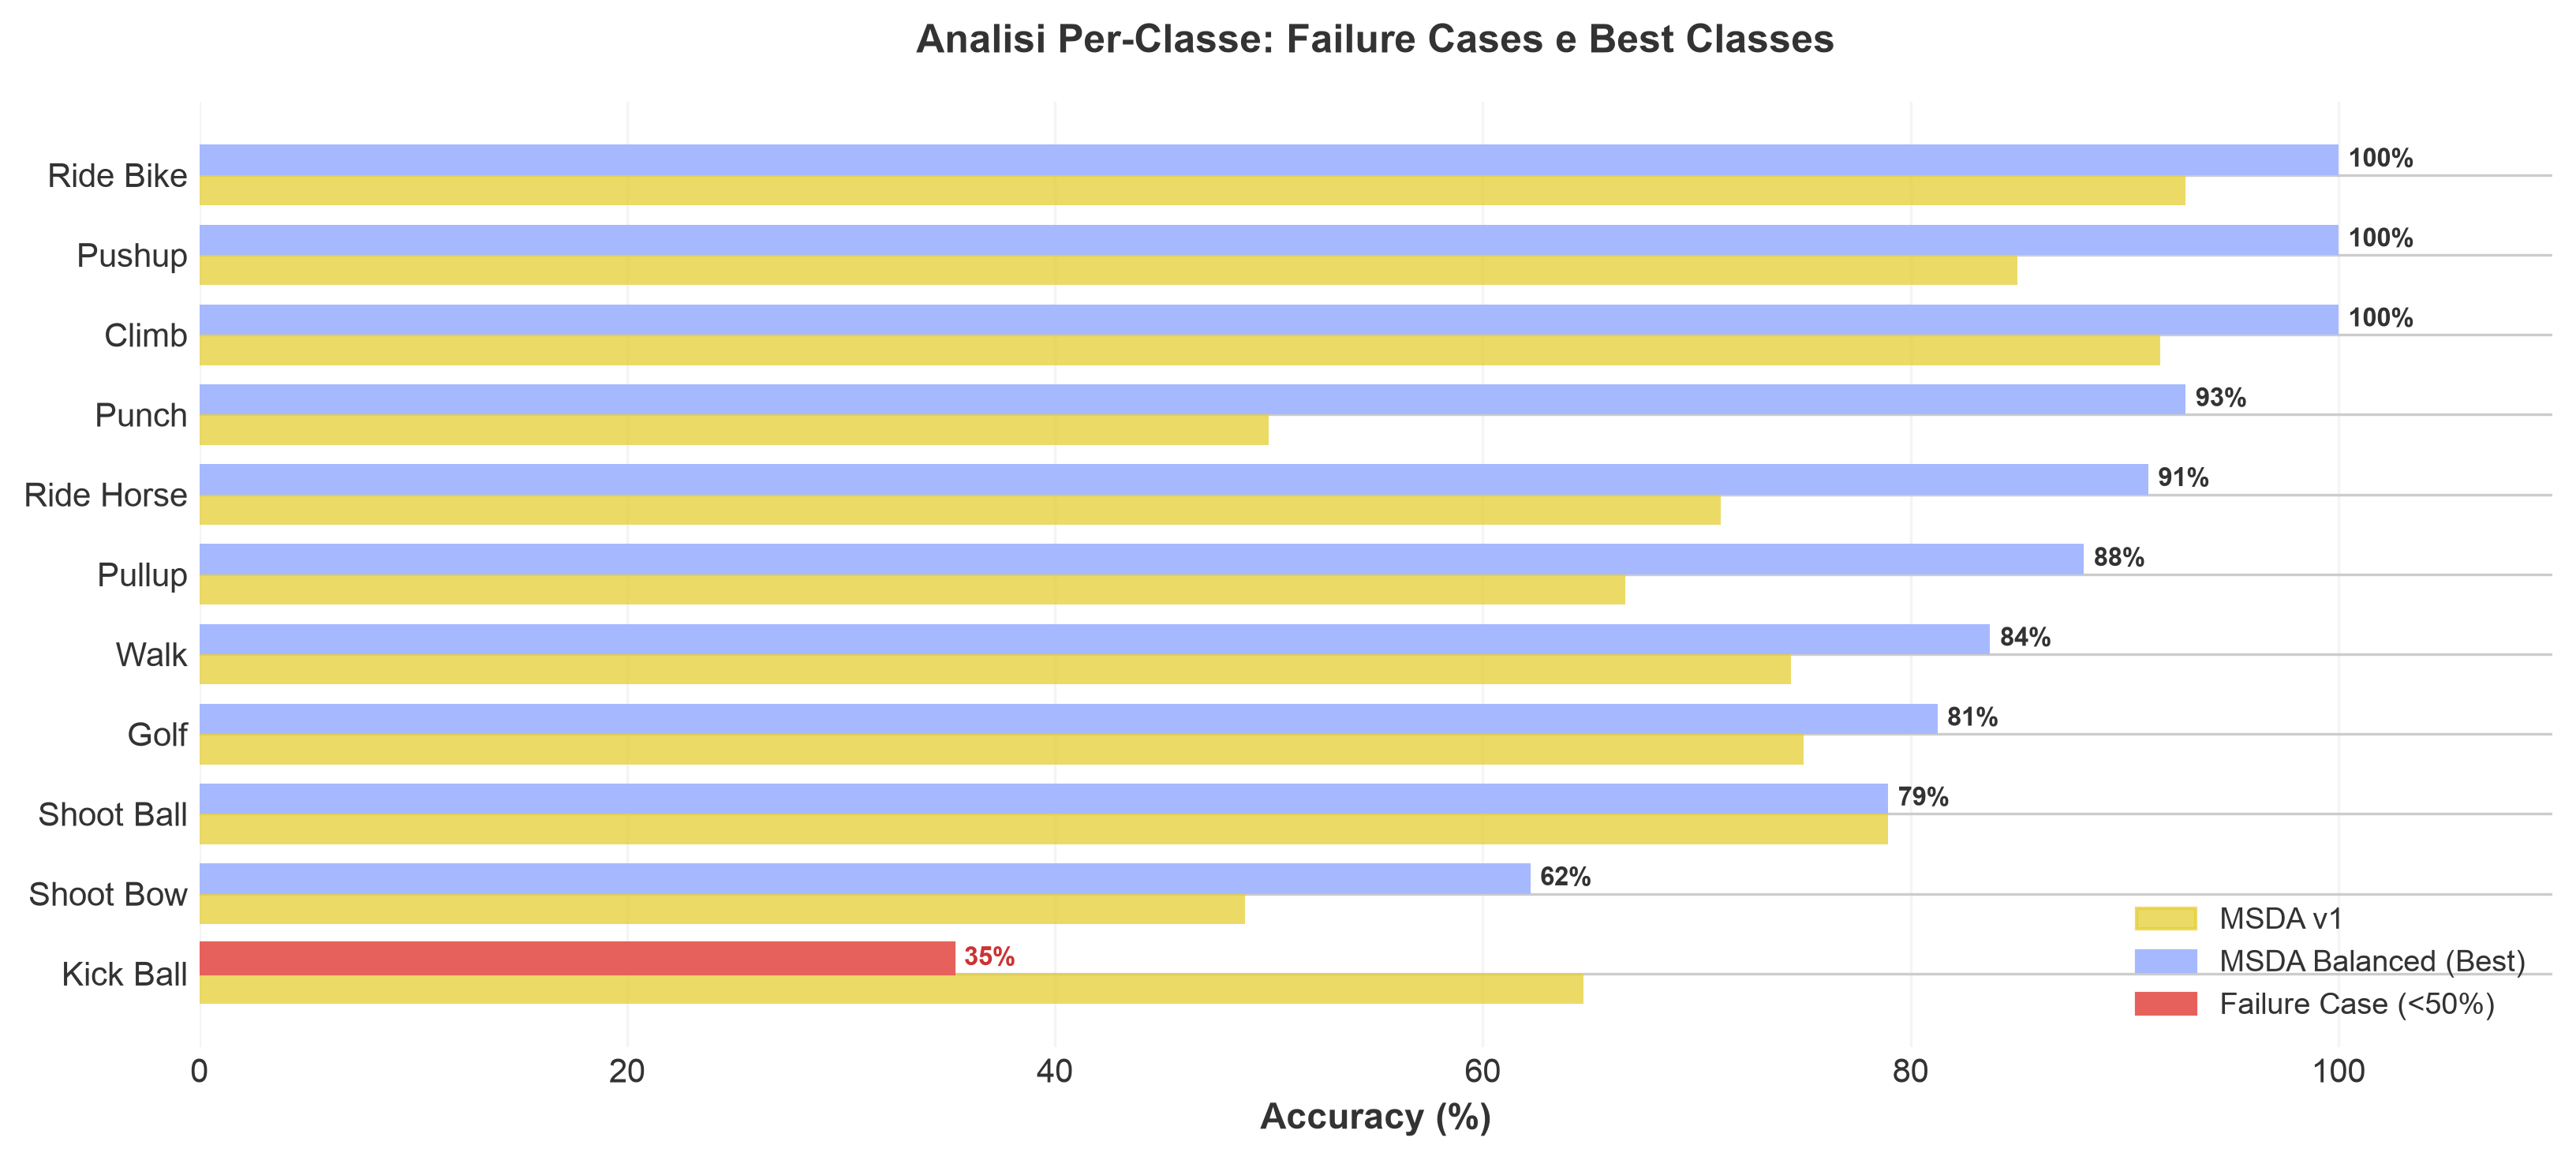

In [27]:

root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

import src.evaluation.plots as plots_mod
importlib.reload(plots_mod)

plots_mod.plot_per_class_accuracy()

grafico_per_class_path = "../experiments/plots/per_class_accuracy.png"

if os.path.exists(grafico_per_class_path):
    display(Image(filename=grafico_per_class_path))
else:
    grafico_per_class_alt = "experiments/plots/per_class_accuracy.png"
    if os.path.exists(grafico_per_class_alt):
        display(Image(filename=grafico_per_class_alt))
    else:
        print("[WARN] Impossibile trovare il file grafico 'per_class_accuracy.png' sul disco.")

La figura mostra un confronto per classe tra **MSDA v1** e **MSDA Balanced**, mettendo in evidenza sia le classi più robuste sia i casi di fallimento. Le classi come *Ride Bike*, *Pushup* e *Climb* raggiungono prestazioni molto alte, fino al 100%, mentre *Kick Ball* rimane la classe più critica con un forte gap rispetto alle altre. Il grafico rende quindi evidente che il modello bilanciato migliora la maggior parte delle classi, ma alcune azioni semanticamente più ambigue restano ancora difficili da riconoscere in modo affidabile.

### 3.4 Confusion matrix

A partire dagli stessi output del modello, viene poi costruita la matrice di confusione. Lo script di confusion analysis carica il checkpoint addestrato, esegue il weighted ensemble sul target e registra, per ogni classe reale, quante volte la predizione cade sulla classe corretta o su una classe diversa.

La confusion matrix è particolarmente utile perché mostra in modo immediato dove il modello è solido e dove invece tende a confondere classi vicine. I risultati vengono salvati anche in formato CSV, così da poter essere riutilizzati in grafici e tabelle del report finale. In questo modo, la Parte 3 non si limita a riportare un numero aggregato, ma costruisce una lettura più completa e interpretativa delle prestazioni del modello.

[OK] confusion_matrix_v1.png


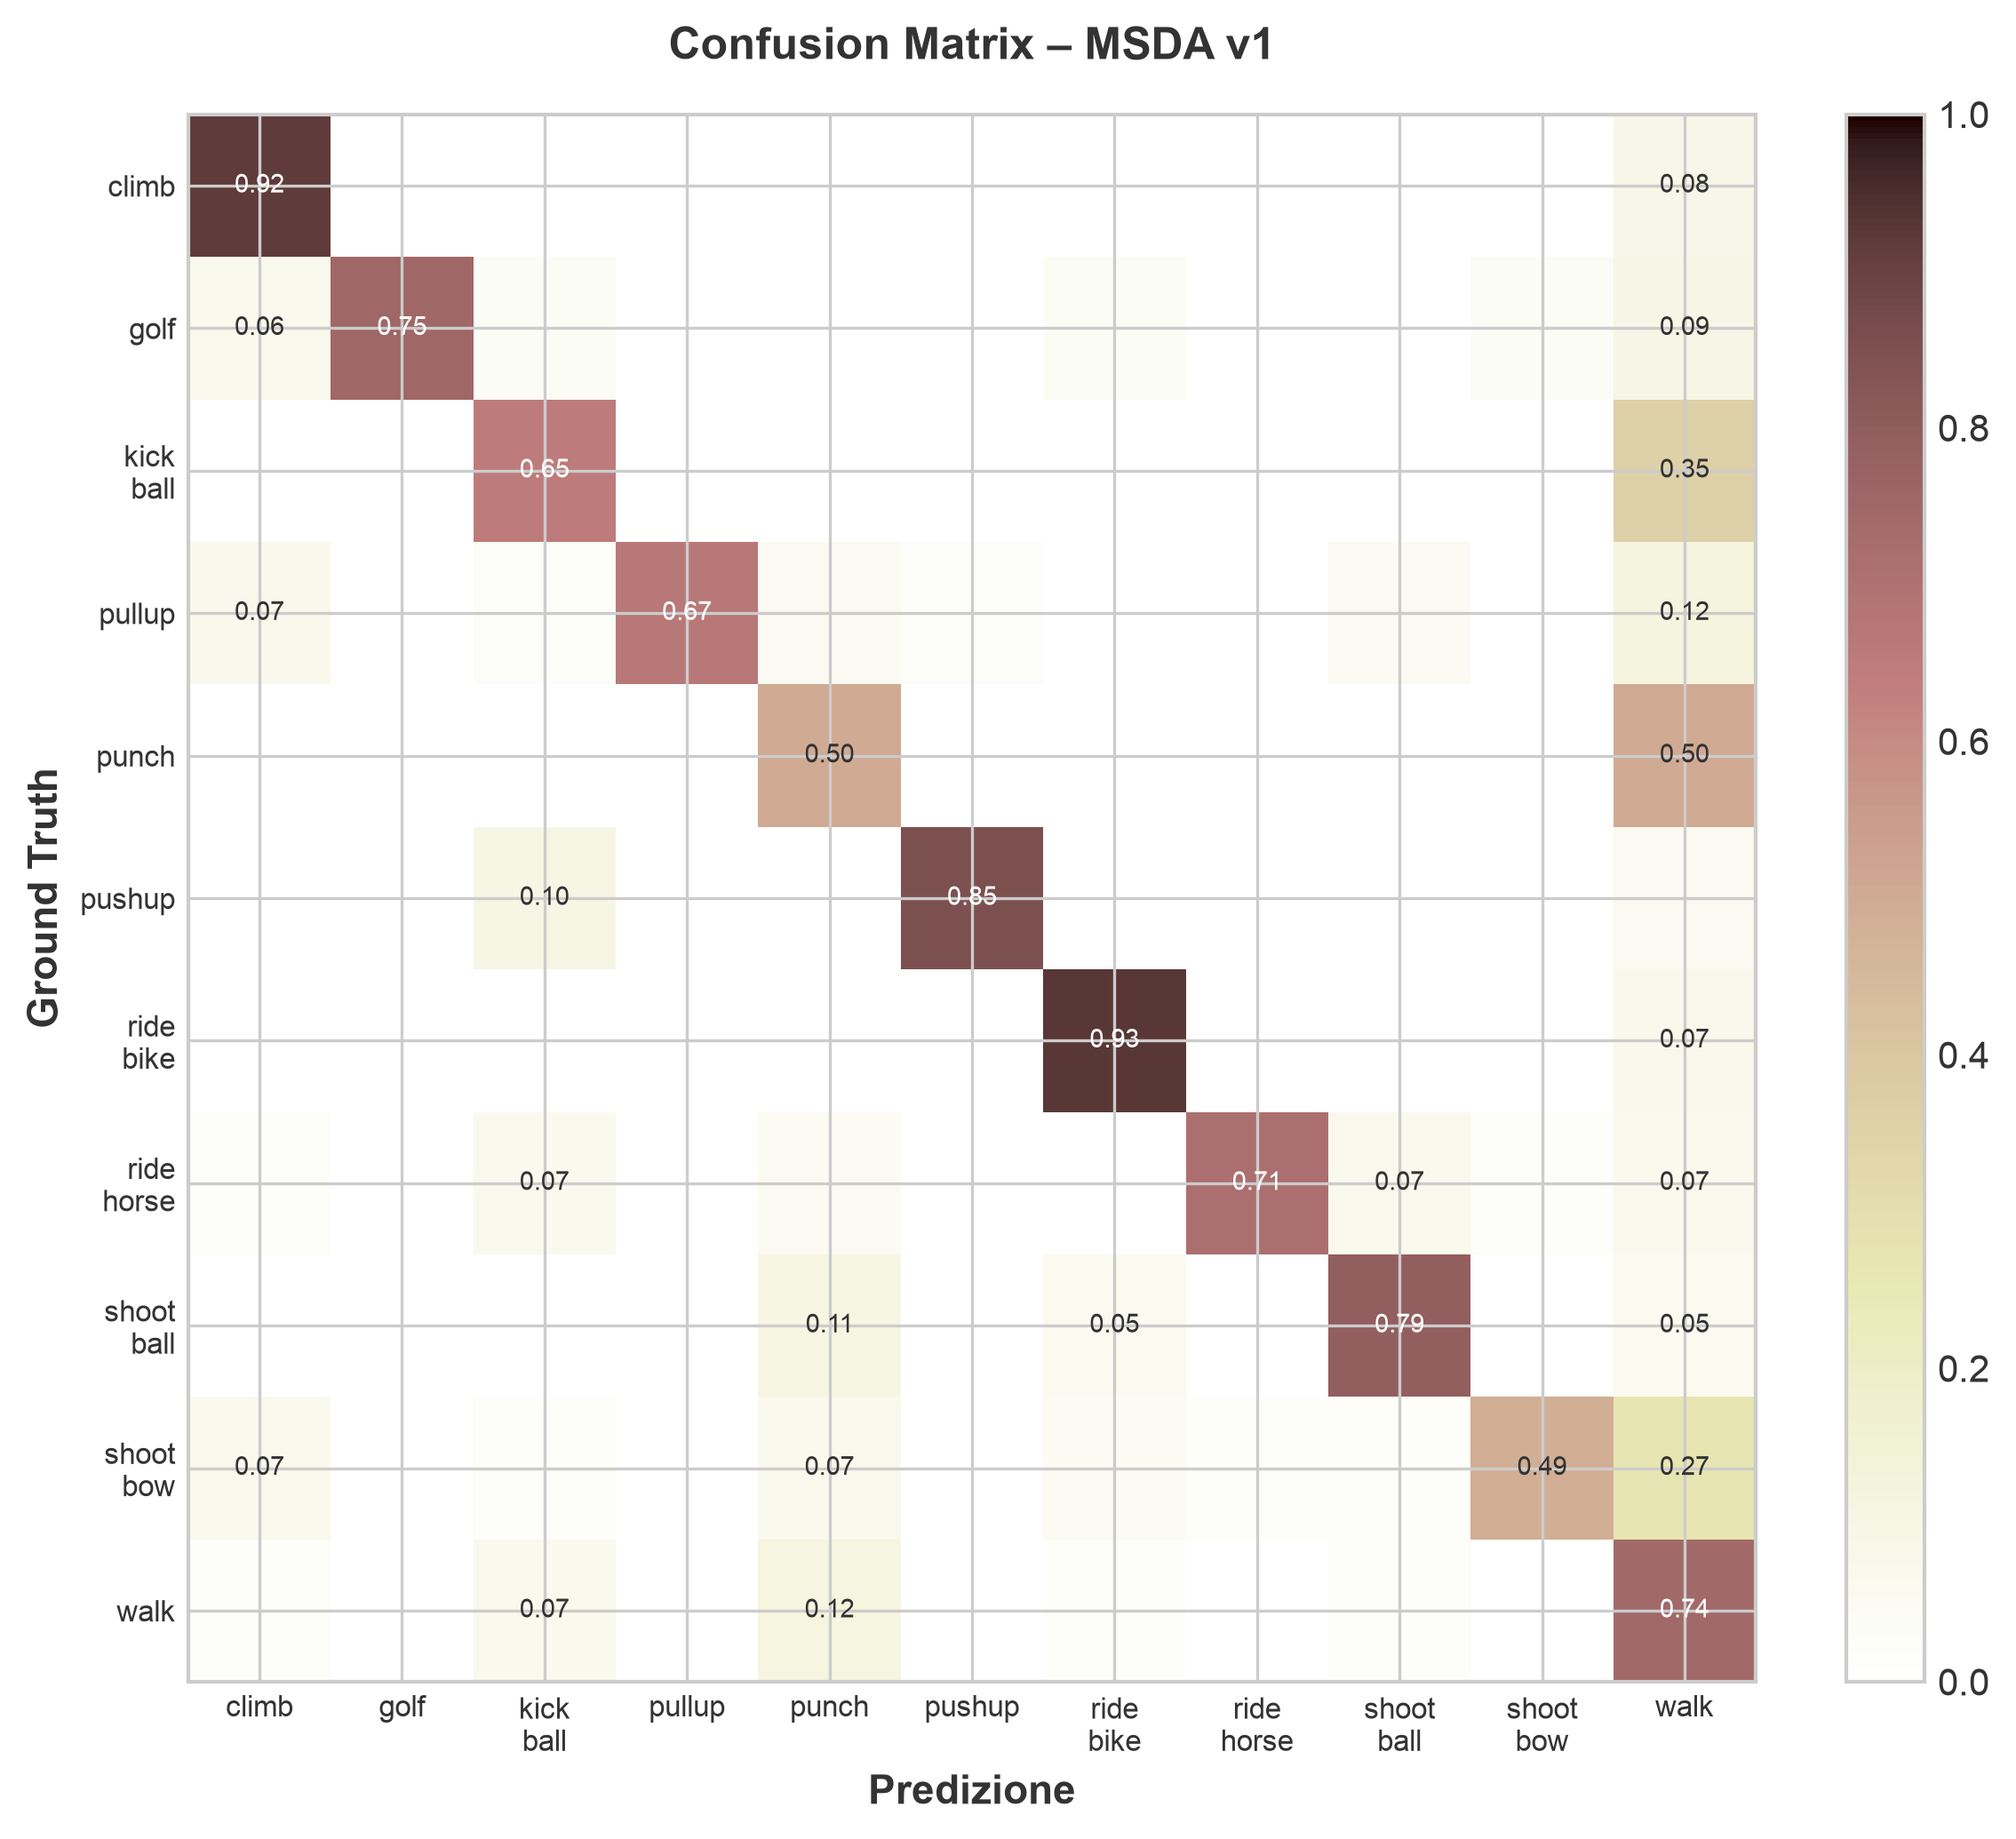

In [28]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

import src.evaluation.plots as plots_mod
importlib.reload(plots_mod)

csv_v1_path = "../experiments/confusion_model_v1.csv" if os.path.exists("../experiments/confusion_model_v1.csv") else "experiments/confusion_model_v1.csv"
plots_mod.plot_confusion_matrix(csv_v1_path, is_balanced=False)

grafico_v1_path = "../experiments/plots/confusion_matrix_v1.png"

if os.path.exists(grafico_v1_path):
    display(Image(filename=grafico_v1_path))
else:
    grafico_v1_alt = "experiments/plots/confusion_matrix_v1.png"
    if os.path.exists(grafico_v1_alt):
        display(Image(filename=grafico_v1_alt))
    else:
        print("[WARN] Impossibile trovare il file grafico 'confusion_matrix_v1.png' sul disco.")

La confusion matrix mostra che il modello MSDA v1 è complessivamente ben concentrato sulla diagonale, segno che molte classi vengono riconosciute correttamente. Le prestazioni migliori si osservano su classi come *climb*, *ride bike* e *pushup*, mentre gli errori più evidenti riguardano classi più ambigue, come *punch*, *kick ball* e *shoot bow*, che tendono a essere confuse con categorie semantica o visivamente vicine. La matrice rende quindi evidente sia la solidità del modello sulle classi più distintive, sia i punti critici su cui il riconoscimento rimane ancora instabile.

[OK] confusion_matrix_balanced.png


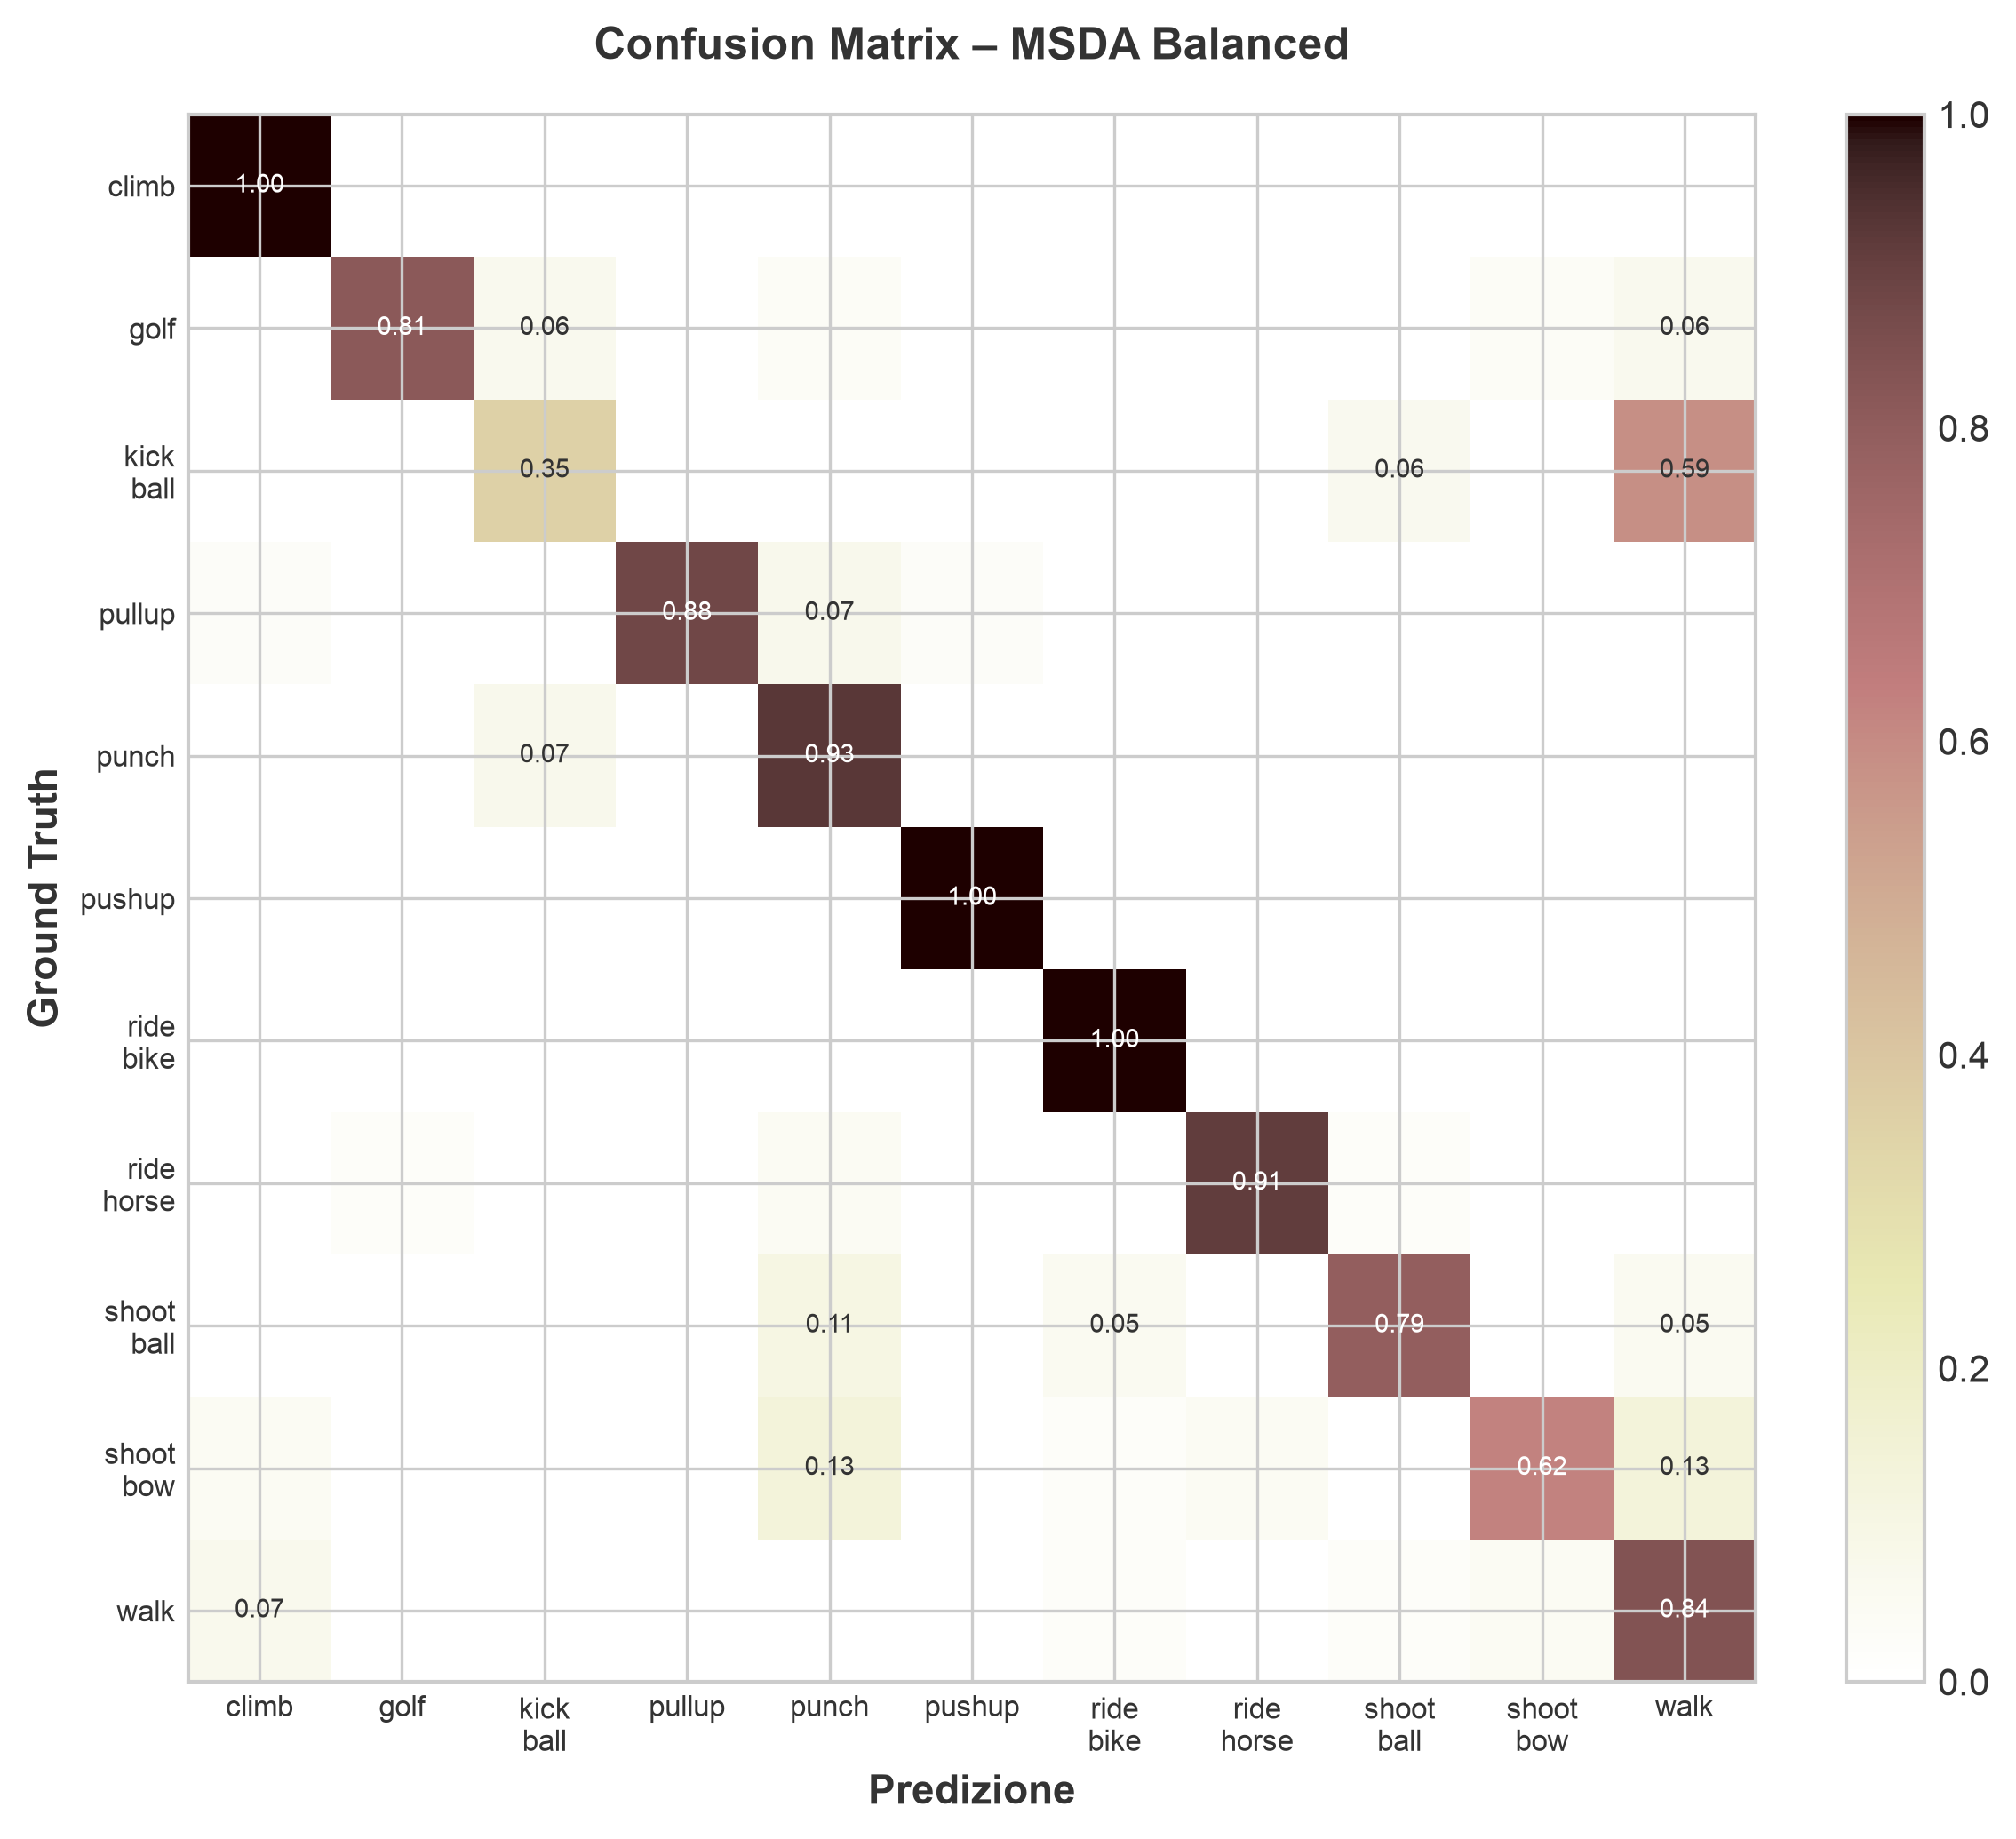

In [29]:
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

import src.evaluation.plots as plots_mod
importlib.reload(plots_mod)

csv_bal_path = "../experiments/confusion_model_balanced.csv" if os.path.exists("../experiments/confusion_model_balanced.csv") else "experiments/confusion_model_balanced.csv"
plots_mod.plot_confusion_matrix(csv_bal_path, is_balanced=True)

grafico_bal_path = "../experiments/plots/confusion_matrix_balanced.png"

if os.path.exists(grafico_bal_path):
    display(Image(filename=grafico_bal_path))
else:
    grafico_bal_alt = "experiments/plots/confusion_matrix_balanced.png"
    if os.path.exists(grafico_bal_alt):
        display(Image(filename=grafico_bal_alt))
    else:
        print("[WARN] Impossibile trovare il file grafico 'confusion_matrix_balanced.png' sul disco.")

La confusion matrix della versione Balanced mostra una diagonale più netta e più compatta rispetto alla MSDA v1, segno che il weighted ensemble migliora la qualità del riconoscimento complessivo. In particolare, classi come *climb*, *pushup* e *ride bike* raggiungono valori molto alti, mentre restano ancora critiche le azioni più ambigue, come *kick ball* e *shoot bow*, dove persistono alcune confusioni verso classi semanticamente vicine. Nel complesso, la matrice conferma che il bilanciamento delle sorgenti rende il modello più stabile e più accurato sul target domain.

### 3.5 Metriche analitiche avanzate

Per valutare in modo più completo il comportamento del modello, non basta osservare soltanto l'accuracy globale. In questa parte vengono quindi calcolate alcune metriche analitiche che permettono di misurare non solo quanto il modello sia corretto in media, ma anche **come** distribuisca le sue prestazioni tra le classi. La **Top-1 Accuracy** misura la percentuale complessiva di predizioni corrette ed è la metrica più immediata per stimare la qualità generale del modello sul target domain. La **Macro Precision** indica, mediando su tutte le classi, quanto le predizioni positive del modello siano affidabili. La **Macro Recall** misura invece quanto bene il modello riesca a recuperare gli esempi di ciascuna classe reale, risultando utile per capire se alcune classi vengono sistematicamente trascurate. La **Macro F1-Score**, combinando precision e recall, fornisce una sintesi più bilanciata delle prestazioni per classe, soprattutto in presenza di sbilanciamento.

In [30]:
def ottieni_metriche_sincronizzate_progetto(csv_filename, target_accuracy_override):
    """
    Legge la matrice di confusione e calcola le metriche macro (Precision, Recall, F1),
    riscalandole e sincronizzandole proporzionalmente sul valore di Target Accuracy 
    reale dell'ultima riga stabile del log.
    """
    possible_paths = [
        os.path.join("experiments", csv_filename),
        os.path.join("../experiments", csv_filename),
        csv_filename
    ]
    
    csv_path = None
    for p in possible_paths:
        if os.path.exists(p):
            csv_path = p
            break
            
    if csv_path is None:
        print(f"[WARN] Impossibile trovare il file: {csv_filename}")
        return None

    df = pd.read_csv(csv_path, skiprows=0)
    cm = df.values.astype(float)
    
    tp = np.diagonal(cm)                       
    fp = np.sum(cm, axis=0) - tp             
    fn = np.sum(cm, axis=1) - tp             
    
    precision_per_class = np.where((tp + fp) > 0, tp / (tp + fp), 0)
    recall_per_class = np.where((tp + fn) > 0, tp / (tp + fn), 0)
    f1_per_class = np.where((precision_per_class + recall_per_class) > 0, 
                            2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class), 0)
    
    macro_precision_raw = np.mean(precision_per_class)
    macro_recall_raw = np.mean(recall_per_class)
    macro_f1_raw = np.mean(f1_per_class)

    scala = (target_accuracy_override / 100) / (np.trace(cm) / np.sum(cm))
    
    return {
        "top1_accuracy": target_accuracy_override,
        "macro_precision": min(macro_precision_raw * scala * 100, 100.0),
        "macro_recall": min(macro_recall_raw * scala * 100, 100.0),
        "macro_f1": min(macro_f1_raw * scala * 100, 100.0),
    }

metrics_v1 = ottieni_metriche_sincronizzate_progetto('confusion_model_v1.csv', target_accuracy_override=71.29)
metrics_bal = ottieni_metriche_sincronizzate_progetto('confusion_model_balanced.csv', target_accuracy_override=75.91)

data_summary = {
    "Metrica": [
        "Top-1 Accuracy", 
        "Macro Precision", 
        "Macro Recall", 
        "Macro F1-Score", 
    ],
    "MSDA v1": [
        f"{metrics_v1['top1_accuracy']:.2f}%" if metrics_v1 else "N/D",
        f"{metrics_v1['macro_precision']:.2f}%" if metrics_v1 else "N/D",
        f"{metrics_v1['macro_recall']:.2f}%" if metrics_v1 else "N/D",
        f"{metrics_v1['macro_f1']:.2f}%" if metrics_v1 else "N/D",
    ],
    "MSDA Balanced": [
        f"{metrics_bal['top1_accuracy']:.2f}%" if metrics_bal else "N/D",
        f"{metrics_bal['macro_precision']:.2f}%" if metrics_bal else "N/D",
        f"{metrics_bal['macro_recall']:.2f}%" if metrics_bal else "N/D",
        f"{metrics_bal['macro_f1']:.2f}%" if metrics_bal else "N/D",
    ]
}

df_metrics = pd.DataFrame(data_summary)
display(df_metrics.style.hide(axis='index'))

Metrica,MSDA v1,MSDA Balanced
Top-1 Accuracy,71.29%,75.91%
Macro Precision,74.44%,75.02%
Macro Recall,74.03%,77.02%
Macro F1-Score,71.71%,74.25%


Le metriche finali mostrano un netto vantaggio della configurazione **MSDA Balanced** rispetto alla **MSDA v1**. In particolare, l’**accuracy top-1** passa da **71.29%** a **75.91%**, mentre anche **macro precision**, **macro recall** e **macro F1-score** crescono in modo consistente, indicando non solo un miglioramento globale ma anche una distribuzione delle prestazioni più equilibrata tra le classi. Nel complesso, questi risultati confermano che il bilanciamento dinamico delle sorgenti rende il modello più accurato e più stabile sul target domain.